## **Libraries Import**

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## **Data Import**

In [77]:
# Carga del dataset
df = pd.read_csv('Data/data.csv', sep=';')

# Limpiar nombres de columnas (tabs y espacios extra)
df.columns = (
    df.columns
    .str.replace('\t', ' ', regex=False)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
 )

# Renombrar columnas clave
df = df.rename(columns={
    'Target': 'Estado',
    'Curricular units 1st sem (grade)': 'first_semester_grade',
    'Curricular units 2nd sem (grade)': 'second_semester_grade'
})

# Filtrar: solo Dropout y Enrolled (excluir Graduate)
df = df[df['Estado'] != 'Graduate'].copy()

# Crear variable target de clasificación: abandona (0=Enrolled, 1=Dropout)
df['abandona'] = df['Estado'].map({'Dropout': 1, 'Enrolled': 0})

# Variable target de regresión
df['promedio_final'] = (df['first_semester_grade'] + df['second_semester_grade']) / 2

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),second_semester_grade,Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Estado,abandona,promedio_final
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0.0,0,10.8,1.4,1.74,Dropout,1,0.00
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,0.0,0,10.8,1.4,1.74,Dropout,1,0.00
7,1,18,4,9254,1,1,119.0,1,37,37,...,5,0,0.0,0,15.5,2.8,-4.06,Dropout,1,0.00
9,1,1,1,9238,1,1,138.0,1,1,19,...,14,2,13.5,0,8.9,1.4,3.51,Dropout,1,12.45
12,1,1,2,9853,1,1,133.0,1,19,37,...,0,0,0.0,0,12.7,3.7,-1.70,Dropout,1,0.00


Se excluye el estado **Graduate** de la variable target para clasificacion puesto que los graduados no son población objetivo para un sistema de alerta temprana, y mezclarlos con **Enrolled** podría confundir al modelo, puesto que el objetivo de estos datos es evitar el abandono academico de estudiantes en etapas tempranas de su carrera.

---
# **Análisis Exploratorio de Datos (EDA)**

In [78]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

EXCLUDE = ["Estado", "abandona", "promedio_final",
           "first_semester_grade", "second_semester_grade", "Curricular units 1st sem (approved)", "Curricular units 2nd sem (approved)"]

cat_nominal = [
    "Marital status", "Application mode", "Course",
    "Previous qualification", "Nacionality",
    "Mother's qualification", "Father's qualification",
    "Mother's occupation",    "Father's occupation"
]
bool_vars = [
    "Daytime/evening attendance", "Displaced",
    "Educational special needs",  "Debtor",
    "Tuition fees up to date",    "Gender",
    "Scholarship holder",         "International"
]
all_feature_cols = [c for c in df.columns if c not in EXCLUDE]
cat_nominal  = [c for c in cat_nominal  if c in df.columns]
bool_vars    = [c for c in bool_vars    if c in df.columns]
numeric_vars = [c for c in all_feature_cols
                if c not in cat_nominal and c not in bool_vars]

Se decidio excluir las columnas de `Estado, abandona, promedio_final, first_semester_grade, second_semester_grade, Curricular units 1st sem (approved), Curricular units 2nd sem (approved)`  puesto que ademas de las variables target, `first_semester_grade`, y `first_semester_grade` se derivan del promedio final del estudiante, y en el diccionario de datos se  confirma que `Curricular units 1st sem (approved)` y `Curricular units 2nd sem (approved)`son "unidades aprobadas", es decir el número de materias que el estudiante pasó. Miran exactamente lo mismo que la nota promedio pero desde otro ángulo: si aprobaste muchas materias, tu nota es alta; si aprobaste pocas o ninguna, eres candidato a Dropout. Son aproximaciones casi perfectas de ambos targets simultáneamente.

---
## **Vista General del Dataset**

  Filas       : 2215
  Columnas    : 39
  Faltantes   : 0
  Duplicados  : 0


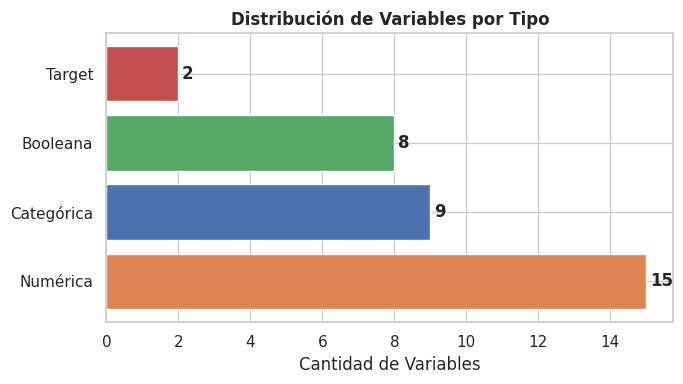

In [79]:
print("=" * 55)
print(f"  Filas       : {df.shape[0]}")
print(f"  Columnas    : {df.shape[1]}")
print(f"  Faltantes   : {df.isnull().sum().sum()}")
print(f"  Duplicados  : {df.duplicated().sum()}")
print("=" * 55)

tipo_df = pd.DataFrame({
    "Tipo": (["Categórica"] * len(cat_nominal) +
             ["Booleana"]           * len(bool_vars)   +
             ["Numérica"]           * len(numeric_vars)+
             ["Target"]             * 2),
    "Variable": cat_nominal + bool_vars + numeric_vars + ["abandona","promedio_final"]
})
conteo = tipo_df["Tipo"].value_counts().reset_index()
conteo.columns = ["Tipo", "Cantidad"]

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#DD8452","#4C72B0","#55A868","#C44E52"]
ax.barh(conteo["Tipo"], conteo["Cantidad"], color=colors, edgecolor="white")
for i, v in enumerate(conteo["Cantidad"]):
    ax.text(v + 0.1, i, str(v), va="center", fontweight="bold")
ax.set_title("Distribución de Variables por Tipo", fontweight="bold")
ax.set_xlabel("Cantidad de Variables")
plt.tight_layout()
plt.show()

---
### **Variables Categóricas**

### Frecuencia de Categorías

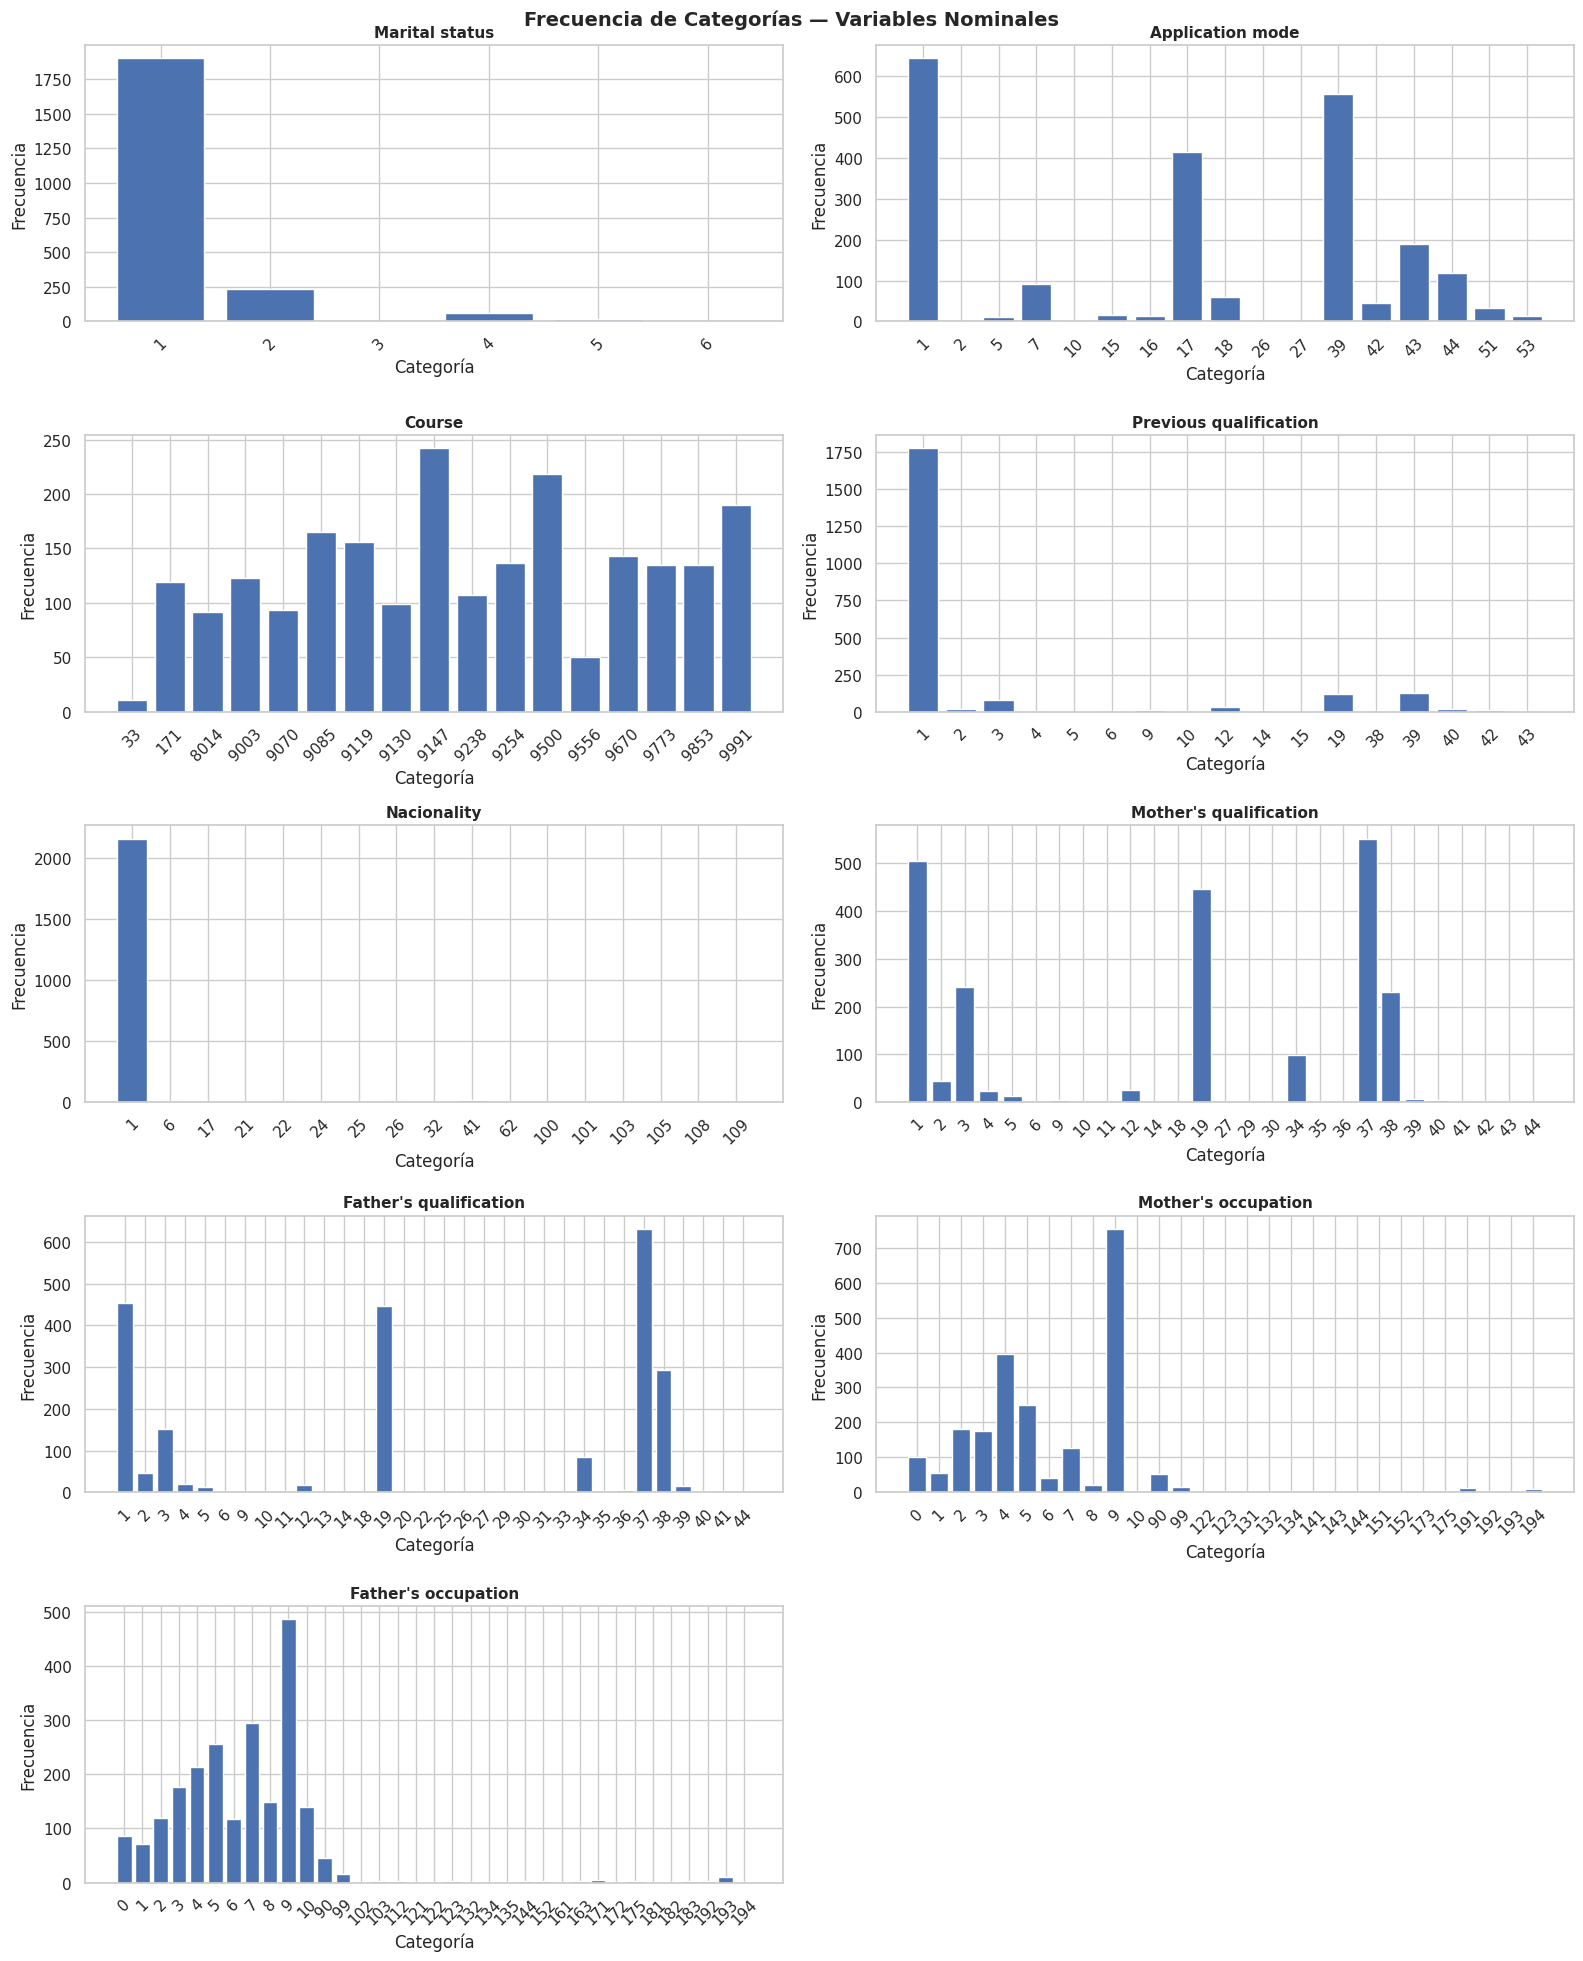

In [80]:
ncols = 2
nrows = int(np.ceil(len(cat_nominal) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_nominal):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values,
                color="#4C72B0", edgecolor="white")
    axes[i].set_title(col, fontweight="bold", fontsize=11)
    axes[i].set_xlabel("Categoría")
    axes[i].set_ylabel("Frecuencia")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Frecuencia de Categorías — Variables Nominales",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Tasa de Abandono por Categoría

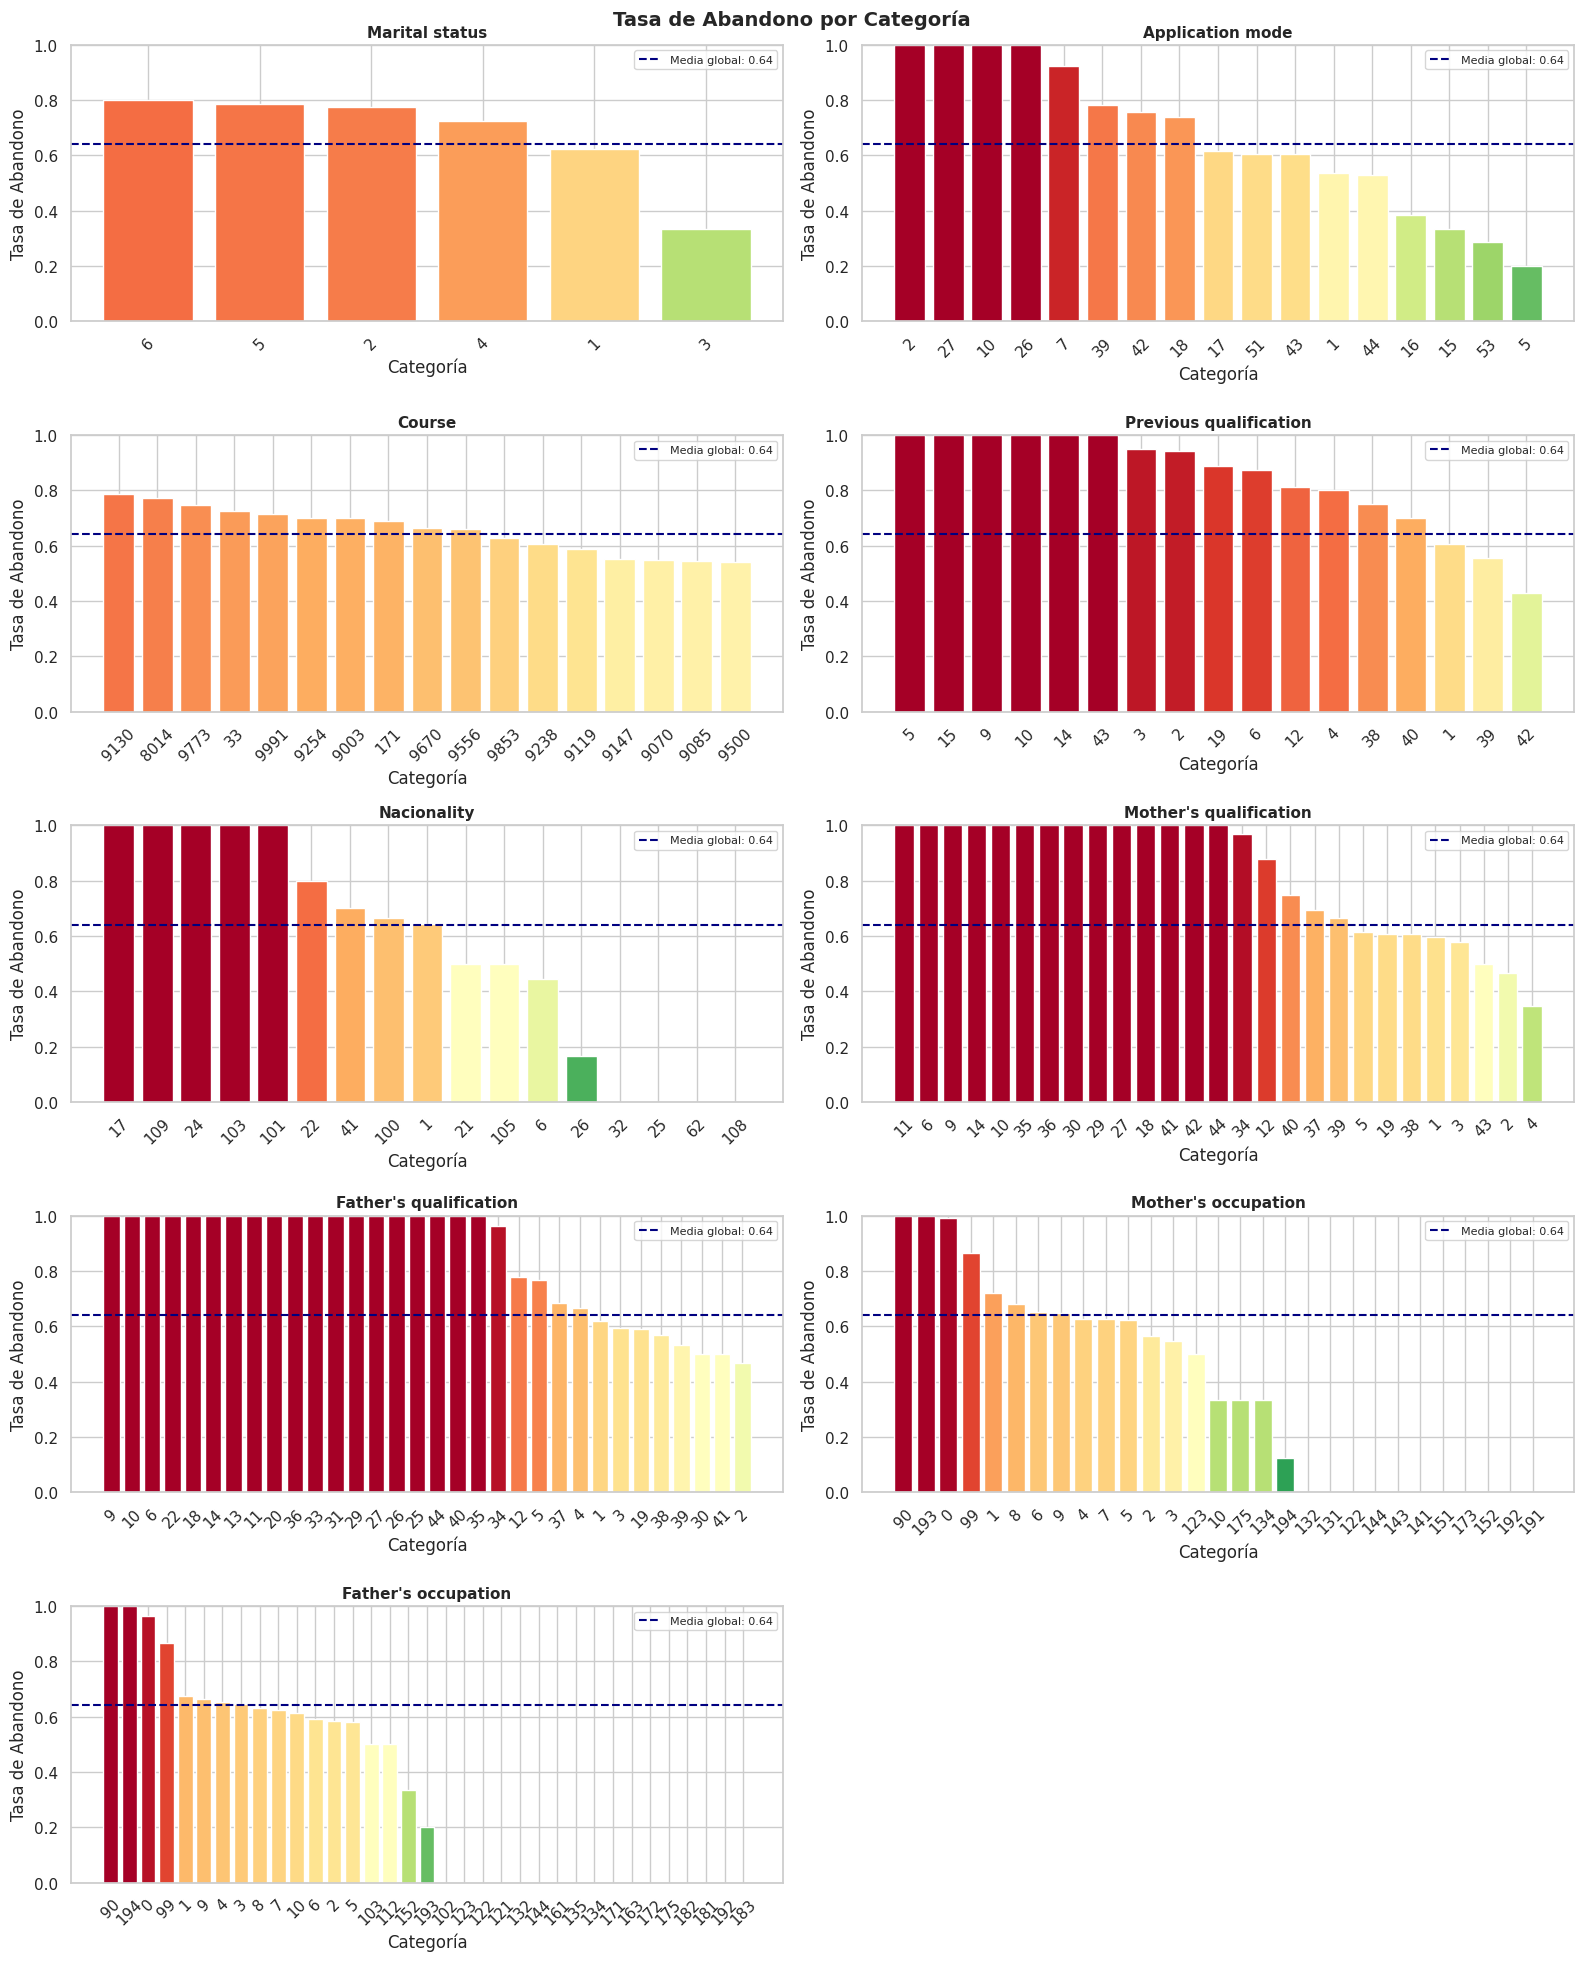

In [81]:
ncols = 2
nrows = int(np.ceil(len(cat_nominal) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_nominal):
    tasa = df.groupby(col)["abandona"].mean().sort_values(ascending=False)
    bars = axes[i].bar(tasa.index.astype(str), tasa.values,
                       color=plt.cm.RdYlGn_r(tasa.values), edgecolor="white")
    axes[i].axhline(df["abandona"].mean(), color="navy",
                    linestyle="--", linewidth=1.5, label=f'Media global: {df["abandona"].mean():.2f}')
    axes[i].set_title(col, fontweight="bold", fontsize=11)
    axes[i].set_xlabel("Categoría")
    axes[i].set_ylabel("Tasa de Abandono")
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Tasa de Abandono por Categoría",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Distribución de `promedio_final` por Categoría

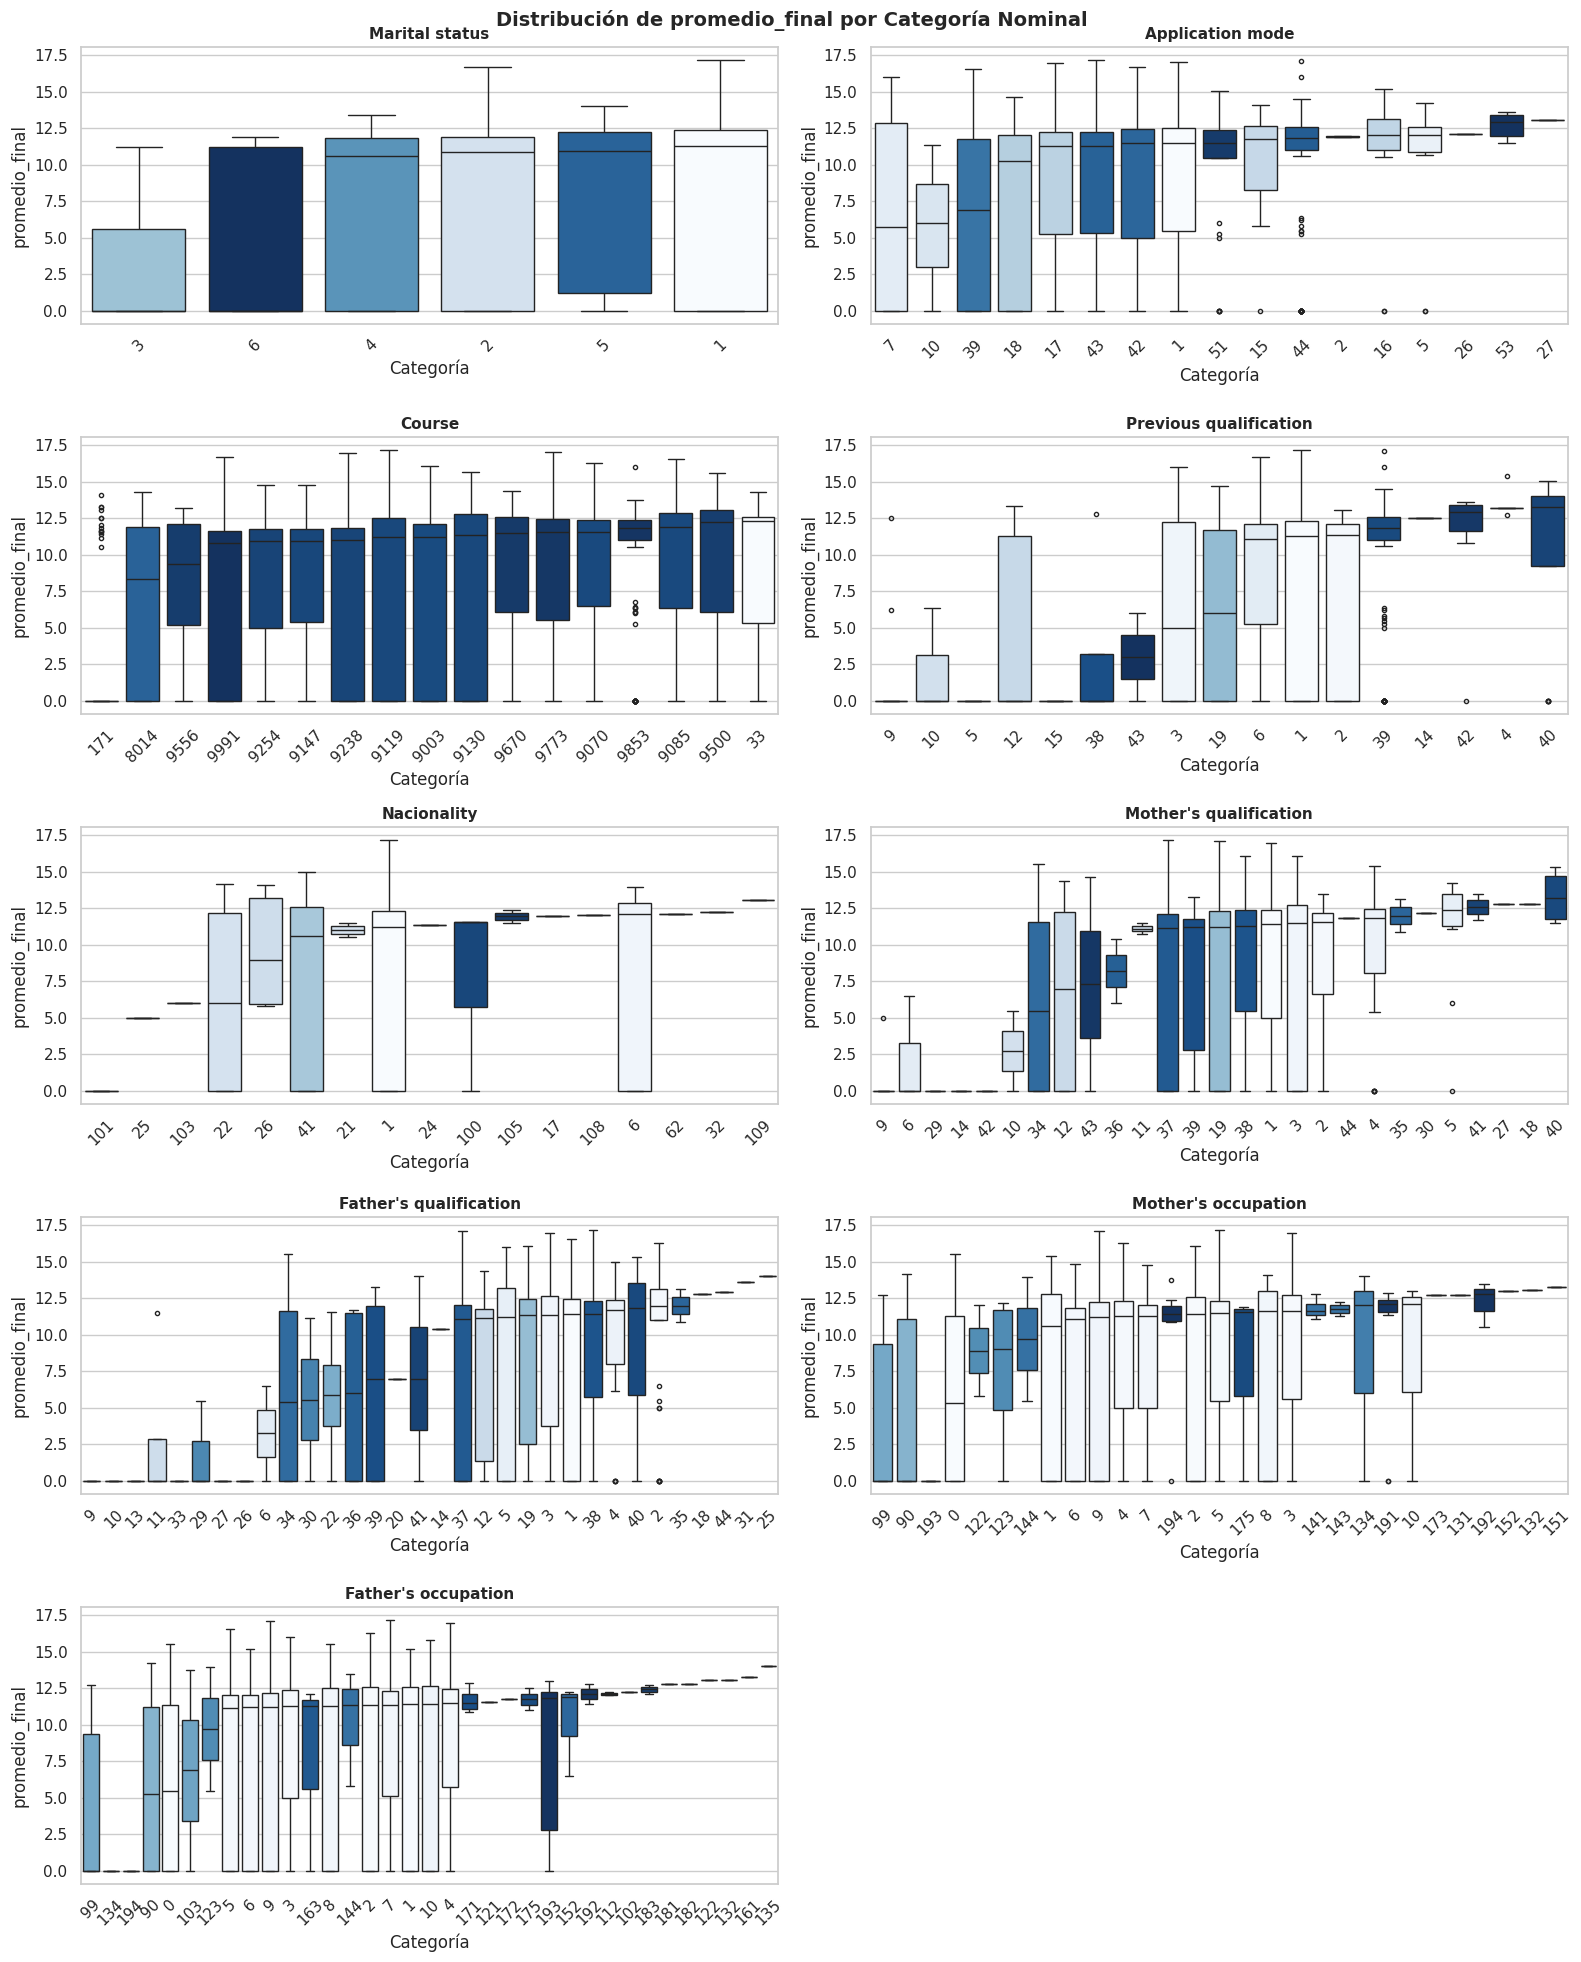

In [82]:
ncols = 2
nrows = int(np.ceil(len(cat_nominal) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_nominal):
    order = df.groupby(col)["promedio_final"].median().sort_values().index
    sns.boxplot(
        data=df, x=col, y="promedio_final",
        order=order, hue=col, legend=False, ax=axes[i],
        palette="Blues", flierprops={"marker":"o","markersize":3}
    )
    axes[i].set_title(col, fontweight="bold", fontsize=11)
    axes[i].set_xlabel("Categoría")
    axes[i].set_ylabel("promedio_final")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de promedio_final por Categoría Nominal",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Tabla de Contingencia con `abandona`

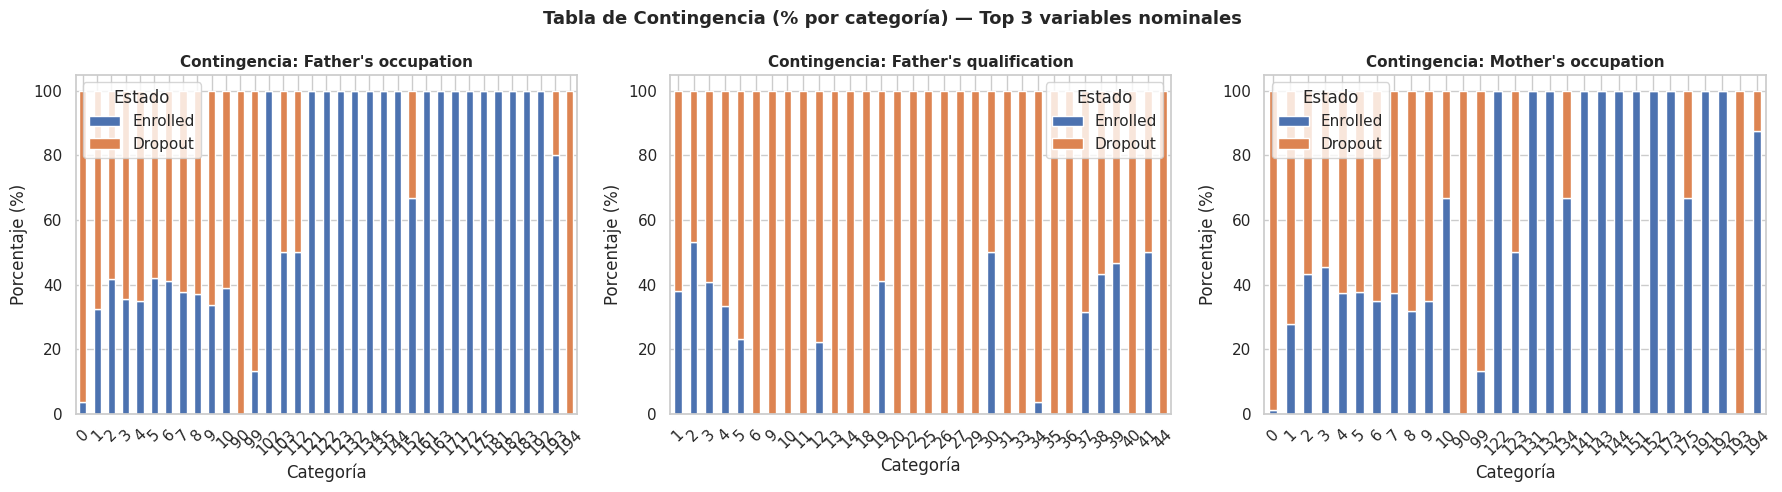


Test Chi-cuadrado (asociación con abandona):
  Variable                                chi2     p-value  Significativa
  -----------------------------------------------------------------
  Marital status                          25.8      0.0001  Sí
  Application mode                       155.7      0.0000  Sí
  Course                                  63.2      0.0000  Sí
  Previous qualification                 103.8      0.0000  Sí
  Nacionality                             18.6      0.2907  No
  Mother's qualification                 101.0      0.0000  Sí
  Father's qualification                  87.4      0.0000  Sí
  Mother's occupation                    166.2      0.0000  Sí
  Father's occupation                    140.0      0.0000  Sí


In [83]:
# Mostramos las 3 variables con más categorías
top_cat_vars = sorted(cat_nominal, key=lambda c: df[c].nunique(), reverse=True)[:3]

fig, axes = plt.subplots(1, len(top_cat_vars), figsize=(18, 5))

for i, col in enumerate(top_cat_vars):
    ct = pd.crosstab(df[col], df["abandona"], normalize="index") * 100
    ct.columns = ["Enrolled", "Dropout"]
    ct.plot(kind="bar", ax=axes[i], color=["#4C72B0","#DD8452"],
            edgecolor="white", stacked=True)
    axes[i].set_title(f"Contingencia: {col}", fontweight="bold", fontsize=11)
    axes[i].set_xlabel("Categoría")
    axes[i].set_ylabel("Porcentaje (%)")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].legend(title="Estado")
    axes[i].set_ylim(0, 105)

plt.suptitle("Tabla de Contingencia (% por categoría) — Top 3 variables nominales",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Chi-cuadrado para todas las nominales
from scipy.stats import chi2_contingency
print("\nTest Chi-cuadrado (asociación con abandona):")
print(f"  {"Variable":<35} {"chi2":>8}  {"p-value":>10}  Significativa")
print("  " + "-"*65)
for col in cat_nominal:
    ct = pd.crosstab(df[col], df["abandona"])
    chi2, p, _, _ = chi2_contingency(ct)
    sig = "Sí" if p < 0.05 else "No"
    print(f"  {col:<35} {chi2:>8.1f}  {p:>10.4f}  {sig}")


### Tasa de Abandono por Grupo

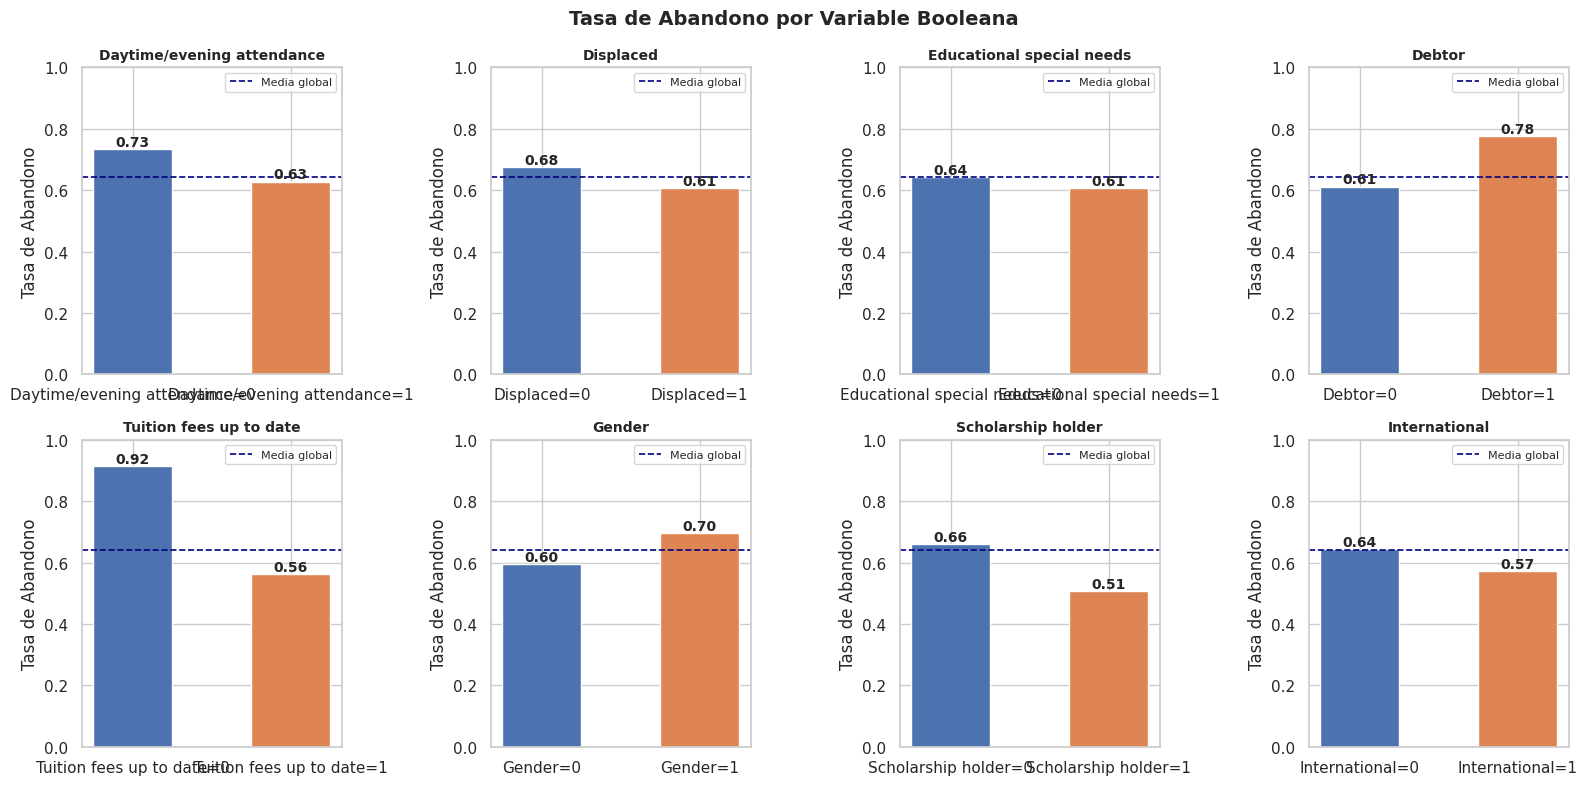

In [84]:
ncols = 4
nrows = int(np.ceil(len(bool_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(bool_vars):
    tasa = df.groupby(col)["abandona"].mean()
    labels = [f"{col}=0", f"{col}=1"]
    bars = axes[i].bar(labels, tasa.values,
                       color=["#4C72B0","#DD8452"], edgecolor="white", width=0.5)
    for bar, val in zip(bars, tasa.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                     f"{val:.2f}", ha="center", fontweight="bold", fontsize=10)
    axes[i].axhline(df["abandona"].mean(), color="navy",
                    linestyle="--", linewidth=1.2, label="Media global")
    axes[i].set_title(col, fontweight="bold", fontsize=10)
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel("Tasa de Abandono")
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Tasa de Abandono por Variable Booleana",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Comparación de `promedio_final` entre Grupos

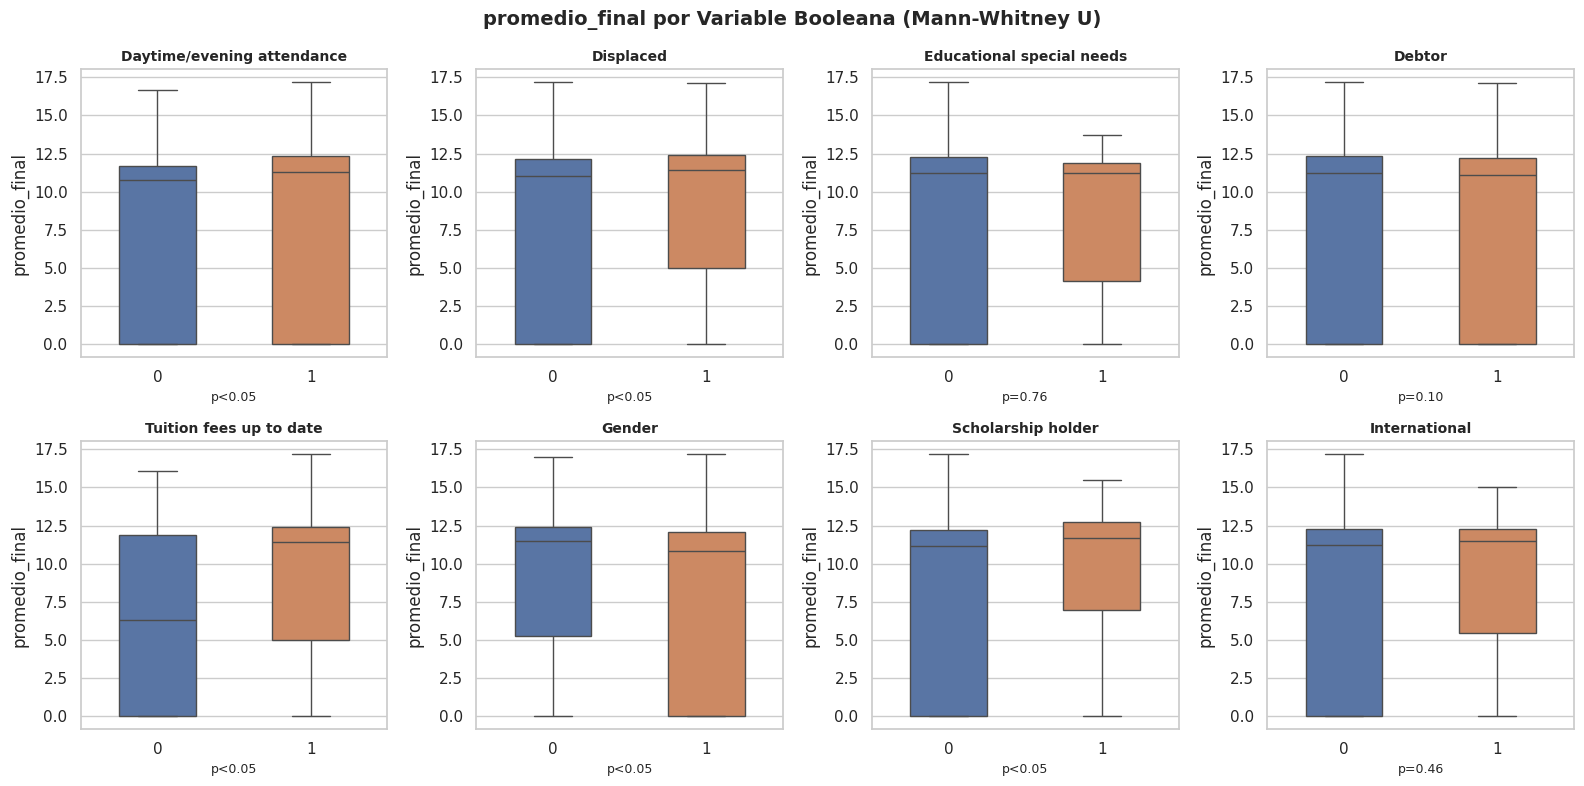

In [85]:
ncols = 4
nrows = int(np.ceil(len(bool_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

from scipy.stats import mannwhitneyu

palette_bin = {0: "#4C72B0", 1: "#DD8452", "0": "#4C72B0", "1": "#DD8452"}

for i, col in enumerate(bool_vars):
    sns.boxplot(
        data=df, x=col, y="promedio_final", hue=col,
        palette=palette_bin, legend=False,
        ax=axes[i], width=0.5,
        flierprops={"marker":"o","markersize":3}
    )
    # Test Mann-Whitney U
    g0 = df[df[col]==0]["promedio_final"]
    g1 = df[df[col]==1]["promedio_final"]
    if len(g0) > 0 and len(g1) > 0:
        _, p = mannwhitneyu(g0, g1, alternative="two-sided")
        sig = "p<0.05" if p < 0.05 else f"p={p:.2f}"
        axes[i].set_xlabel(sig, fontsize=9)
    axes[i].set_title(col, fontweight="bold", fontsize=10)
    axes[i].set_ylabel("promedio_final")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["0", "1"])

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("promedio_final por Variable Booleana (Mann-Whitney U)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Estadísticas Descriptivas por Clase

In [86]:
desc_dropout  = df[df["abandona"]==1][numeric_vars].describe().T
desc_enrolled = df[df["abandona"]==0][numeric_vars].describe().T

desc_combined = desc_dropout[["mean","std","50%"]].copy()
desc_combined.columns = ["mean_dropout","std_dropout","median_dropout"]
desc_combined["mean_enrolled"]   = desc_enrolled["mean"]
desc_combined["std_enrolled"]    = desc_enrolled["std"]
desc_combined["median_enrolled"] = desc_enrolled["50%"]
desc_combined["diff_means"]      = (desc_combined["mean_dropout"]
                                    - desc_combined["mean_enrolled"]).round(3)

print("Estadísticas descriptivas por clase (Dropout vs Enrolled):")
display(desc_combined.round(3).style.background_gradient(
    cmap="RdYlGn_r", subset=["diff_means"]))


Estadísticas descriptivas por clase (Dropout vs Enrolled):


,mean_dropout,std_dropout,median_dropout,mean_enrolled,std_enrolled,median_enrolled,diff_means
Application order,1.593000,1.216000,1.000000,1.626000,1.214000,1.000000,-0.033000
Previous qualification (grade),131.114000,12.873000,133.100000,131.208000,12.872000,130.000000,-0.094000
Admission grade,124.961000,15.125000,123.600000,125.534000,13.793000,124.100000,-0.573000
Age at enrollment,26.069000,8.704000,23.000000,22.369000,6.303000,20.000000,3.700000
Curricular units 1st sem (credited),0.609000,2.105000,0.000000,0.508000,1.716000,0.000000,0.102000
Curricular units 1st sem (enrolled),5.821000,2.326000,6.000000,5.965000,1.988000,6.000000,-0.143000
Curricular units 1st sem (evaluations),7.752000,4.922000,8.000000,9.341000,3.463000,9.000000,-1.590000
Curricular units 1st sem (without evaluations),0.192000,0.795000,0.000000,0.178000,0.741000,0.000000,0.015000
Curricular units 2nd sem (credited),0.450000,1.680000,0.000000,0.359000,1.329000,0.000000,0.091000
Curricular units 2nd sem (enrolled),5.780000,2.108000,6.000000,5.938000,1.831000,6.000000,-0.158000


### Histogramas por Clase (Dropout vs Enrolled)

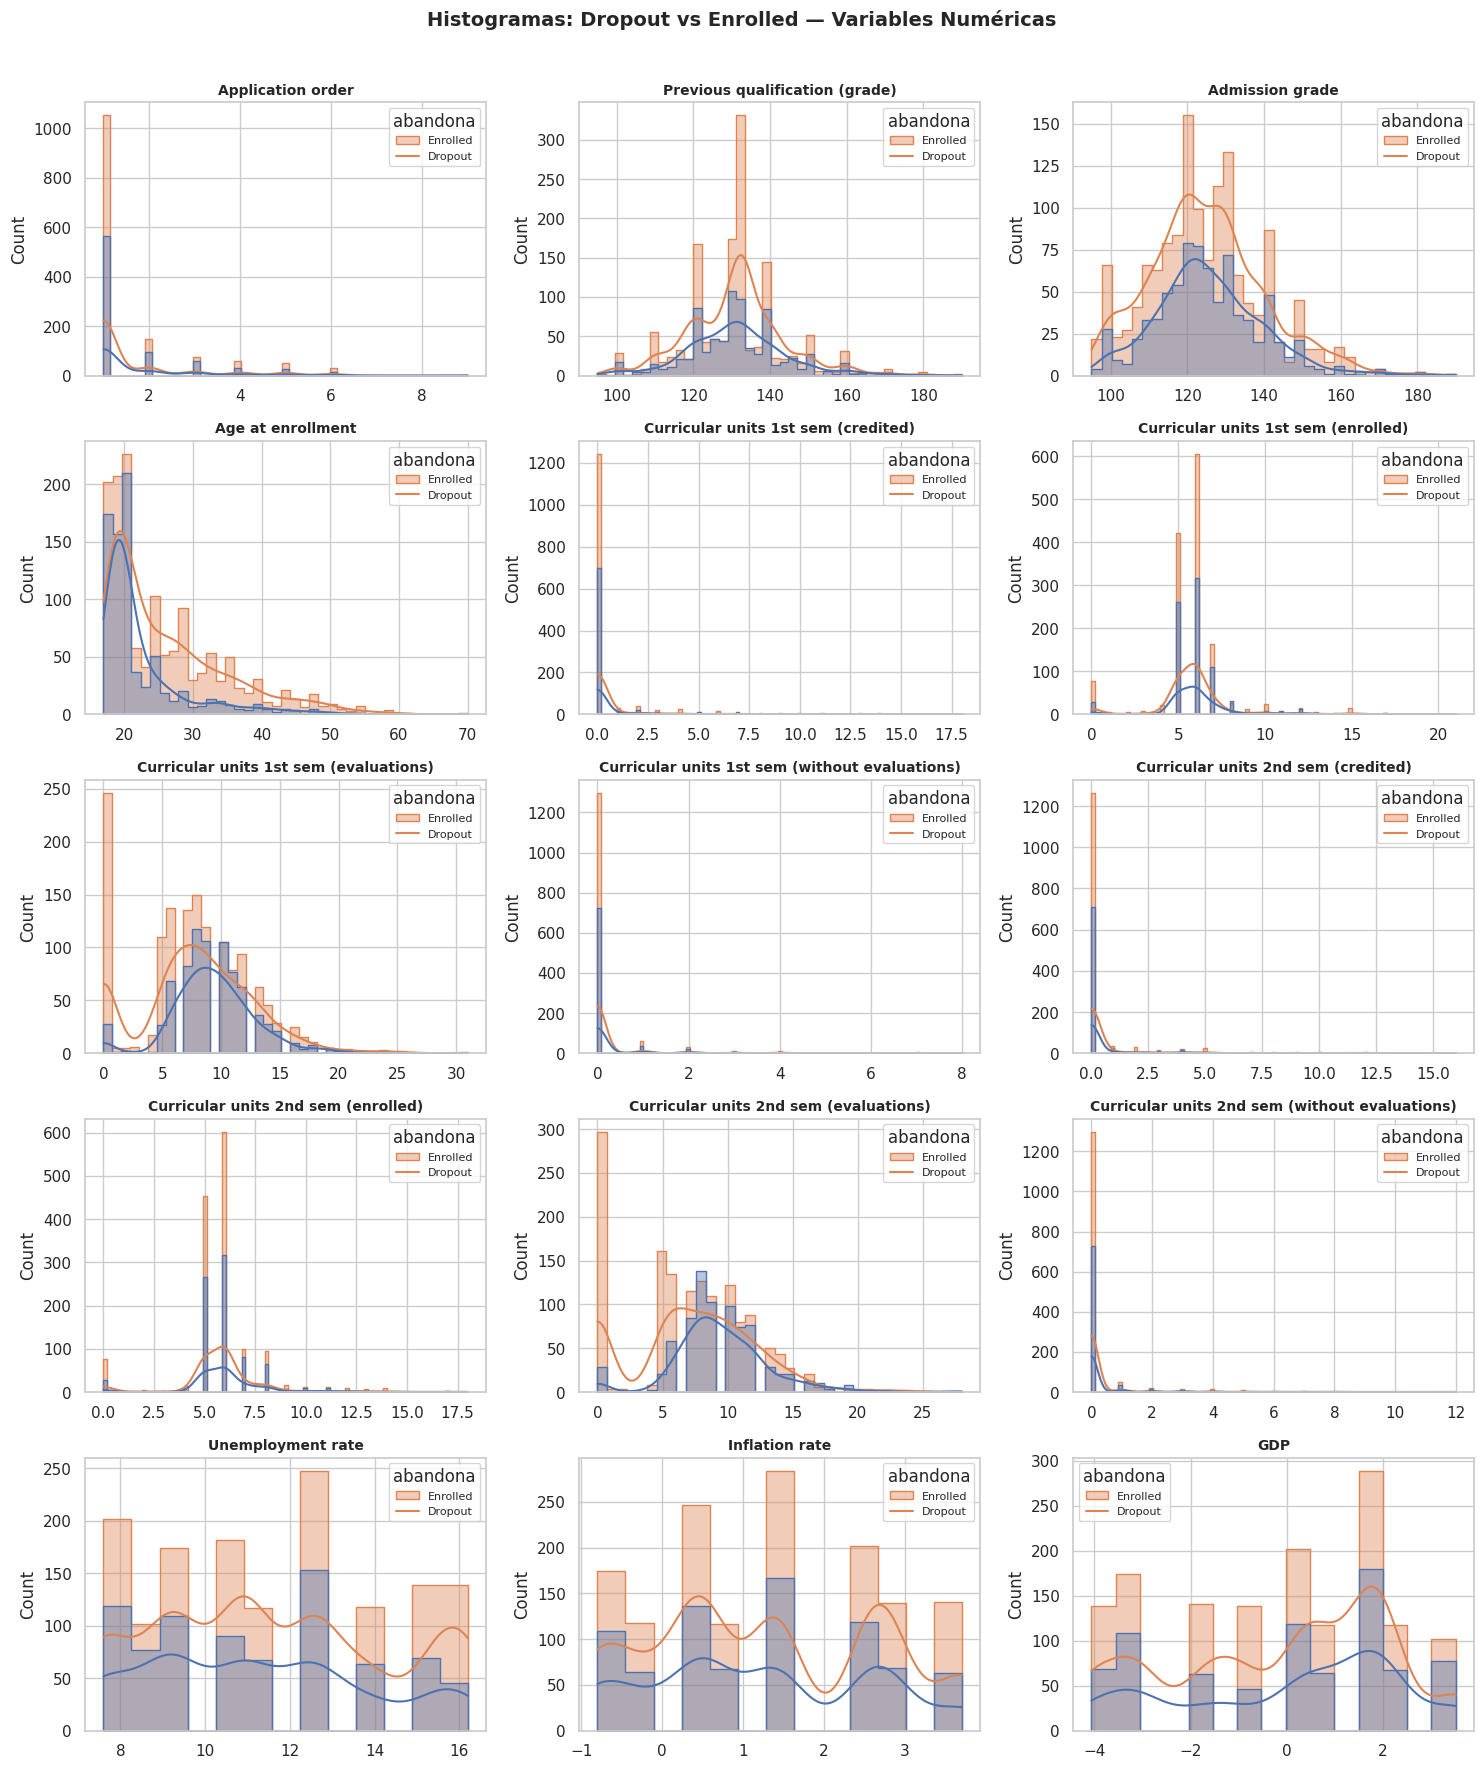

In [87]:
ncols = 3
nrows = int(np.ceil(len(numeric_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_vars):
    sns.histplot(
        data=df, x=col, hue="abandona",
        kde=True, element="step", alpha=0.4,
        palette={0:"#4C72B0", 1:"#DD8452"},
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].legend(title="abandona", labels=["Enrolled","Dropout"], fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Histogramas: Dropout vs Enrolled — Variables Numéricas",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### Boxplots por Clase

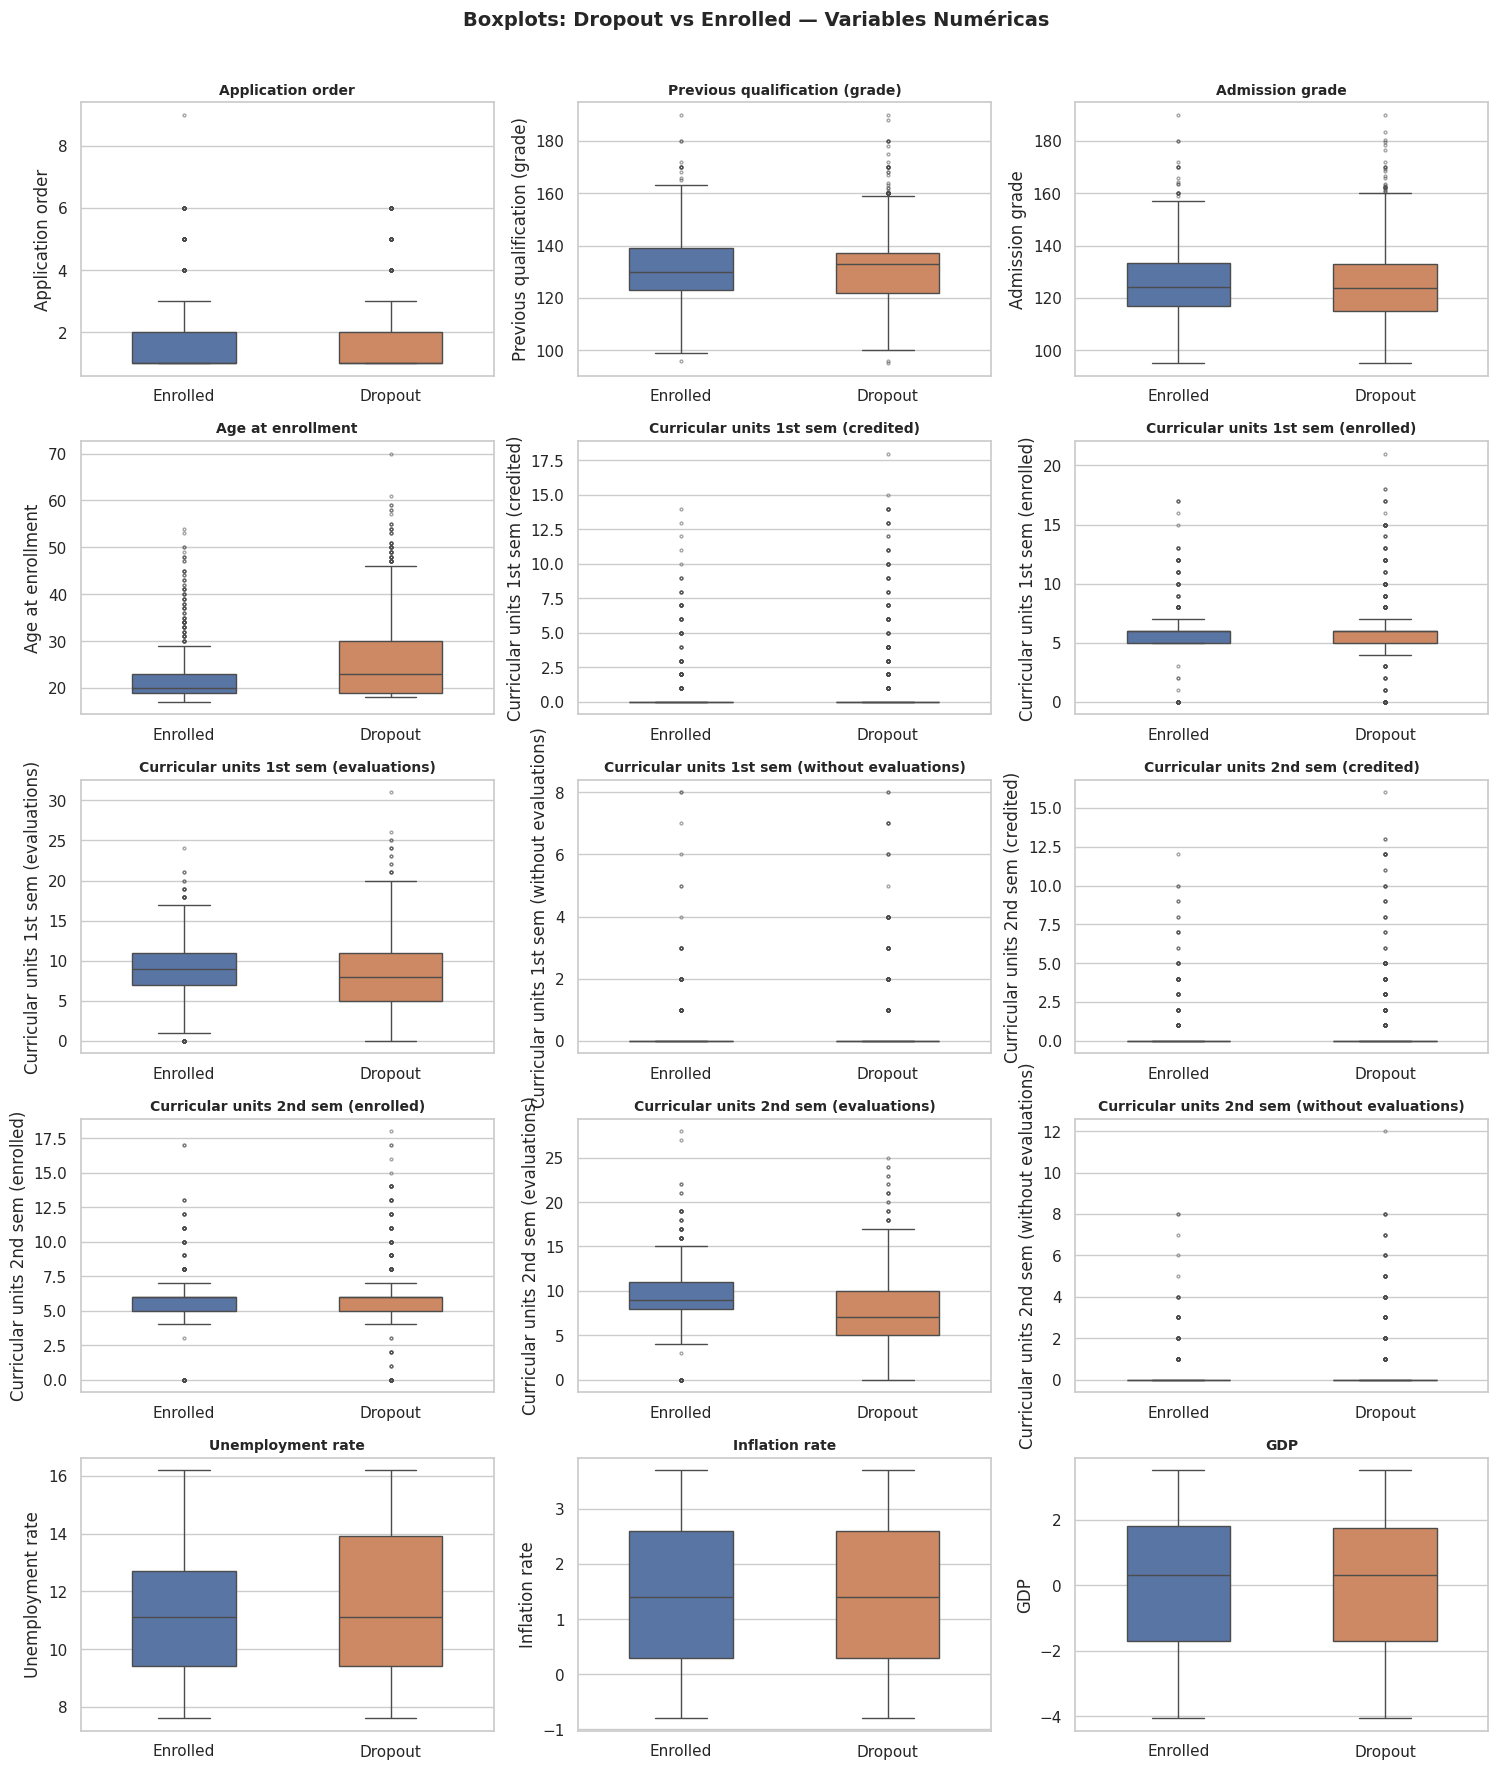

In [88]:
ncols = 3
nrows = int(np.ceil(len(numeric_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes = axes.flatten()

palette_bin = {0: "#4C72B0", 1: "#DD8452", "0": "#4C72B0", "1": "#DD8452"}

for i, col in enumerate(numeric_vars):
    sns.boxplot(
        data=df, x="abandona", y=col, hue="abandona",
        palette=palette_bin, legend=False,
        ax=axes[i], width=0.5,
        flierprops={"marker":"o","markersize":2,"alpha":0.5}
    )
    axes[i].set_title(col, fontsize=10, fontweight="bold")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Enrolled", "Dropout"])

    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots: Dropout vs Enrolled — Variables Numéricas",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


### Matriz de Correlación 

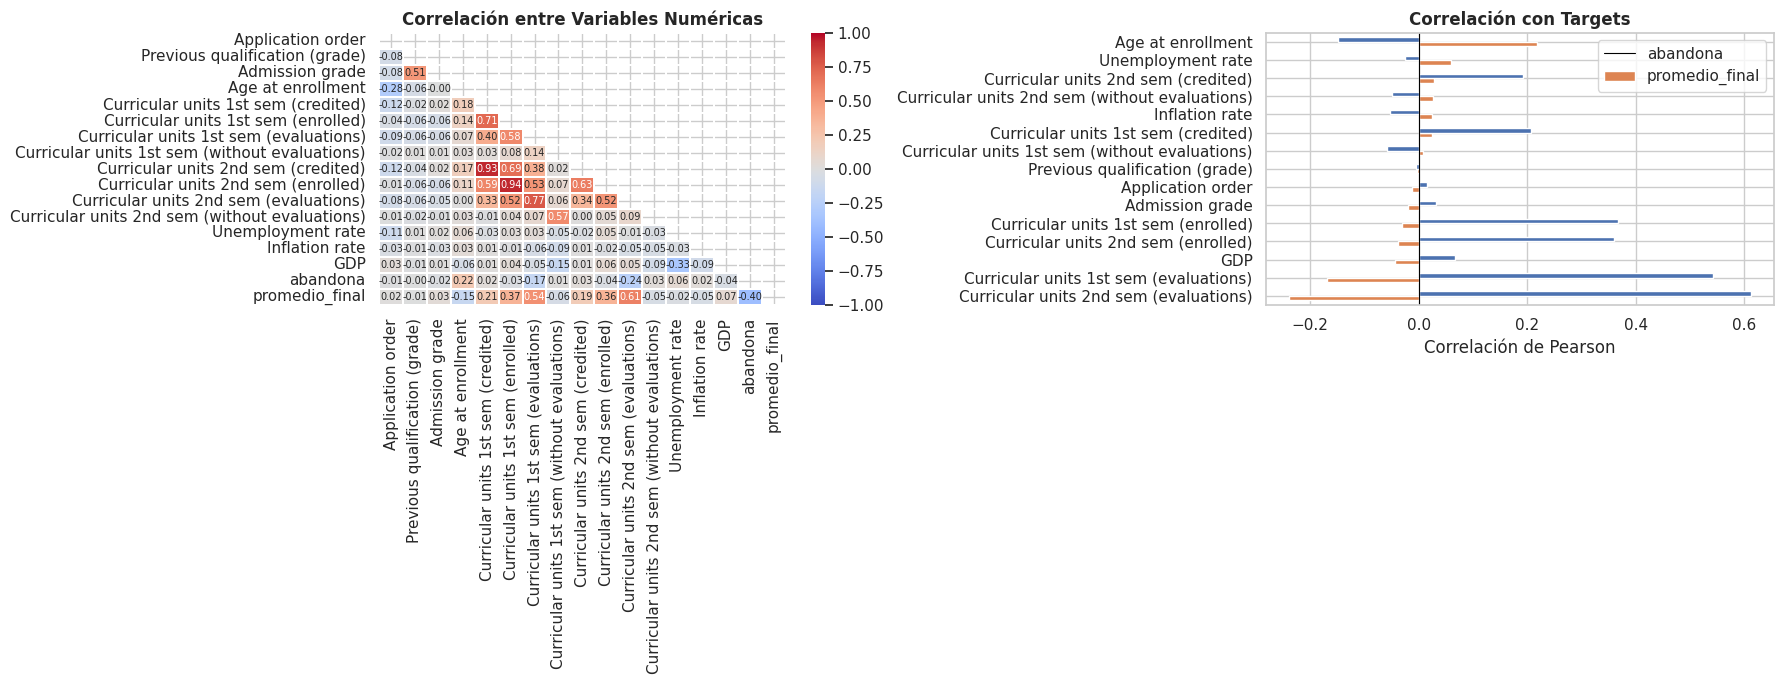

In [89]:
corr_cols = numeric_vars + ["abandona", "promedio_final"]
corr_matrix = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap completo
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.3,
    ax=axes[0], vmin=-1, vmax=1,
    annot_kws={"size": 7}
)
axes[0].set_title("Correlación entre Variables Numéricas", fontweight="bold")

# Correlación con targets (barras)
corr_targets = corr_matrix[["abandona","promedio_final"]]\
                           .drop(["abandona","promedio_final"])\
                           .sort_values("abandona")
corr_targets.plot(kind="barh", ax=axes[1],
                  color=["#DD8452","#4C72B0"], edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlación con Targets", fontweight="bold")
axes[1].set_xlabel("Correlación de Pearson")
axes[1].legend(["abandona","promedio_final"])

plt.tight_layout()
plt.show()


### Variables Target

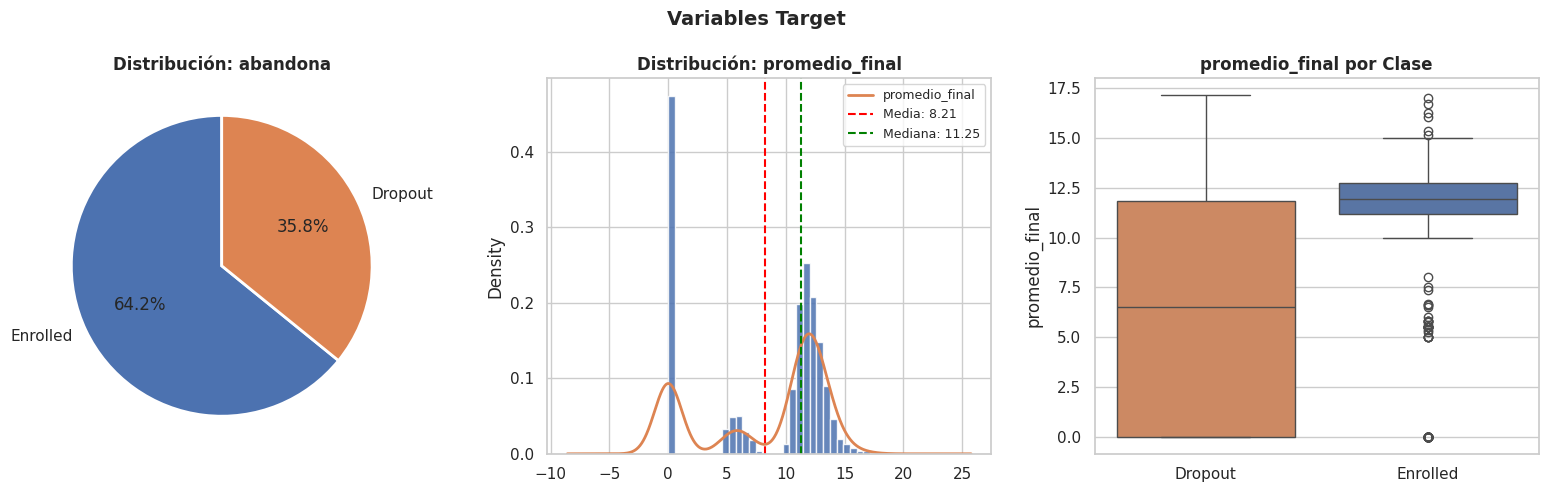


Estadísticas por clase:
           count   mean   std  min    25%    50%    75%    max
abandona                                                      
Enrolled   794.0  11.12  3.41  0.0  11.17  11.92  12.75  17.00
Dropout   1421.0   6.58  5.66  0.0   0.00   6.50  11.86  17.17


In [90]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Target clasificación: distribución
counts = df["abandona"].value_counts()
axes[0].pie(
    counts.values,
    labels=["Enrolled","Dropout"],
    autopct="%1.1f%%",
    colors=["#4C72B0","#DD8452"],
    startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":2}
)
axes[0].set_title("Distribución: abandona", fontweight="bold")

# Target regresión: histograma
axes[1].hist(df["promedio_final"], bins=30,
             color="#4C72B0", edgecolor="white", alpha=0.85, density=True)
df["promedio_final"].plot(kind="kde", ax=axes[1], color="#DD8452", linewidth=2)
axes[1].axvline(df["promedio_final"].mean(), color="red", linestyle="--",
                label=f'Media: {df["promedio_final"].mean():.2f}')
axes[1].axvline(df["promedio_final"].median(), color="green", linestyle="--",
                label=f'Mediana: {df["promedio_final"].median():.2f}')
axes[1].set_title("Distribución: promedio_final", fontweight="bold")
axes[1].legend(fontsize=9)

# promedio_final por clase
df_box = df[["promedio_final","abandona"]].copy()
df_box["Clase"] = df_box["abandona"].map({0:"Enrolled",1:"Dropout"})
sns.boxplot(data=df_box, x="Clase", y="promedio_final", hue="Clase",
            palette={"Enrolled":"#4C72B0","Dropout":"#DD8452"},
            legend=False, ax=axes[2])
axes[2].set_title("promedio_final por Clase", fontweight="bold")
axes[2].set_xlabel("")

plt.suptitle("Variables Target", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nEstadísticas por clase:")
print(df.groupby("abandona")["promedio_final"]
        .describe().round(2)
        .rename(index={0:"Enrolled",1:"Dropout"}))


---
## Resumen del EDA

SOme text

---
# **Preprocesamiento**

## **División Train (80%) / Validation (20%) / Test(20%)**

In [91]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED  = 42

X_raw = df[all_feature_cols]
y_clf = df["abandona"].values
y_reg = df["promedio_final"].values

# 1) Apartar Test (20 %)
X_temp, X_test_raw, y_clf_temp, y_clf_test = train_test_split(
    X_raw, y_clf, test_size=0.20, random_state=SEED, stratify=y_clf)
_,      _,          y_reg_temp,  y_reg_test  = train_test_split(
    X_raw, y_reg, test_size=0.20, random_state=SEED)

# 2) Del 80 % restante apartar Validation (20 % de 80 %)
X_train_raw, X_val_raw, y_clf_train, y_clf_val = train_test_split(
    X_temp, y_clf_temp, test_size=0.20, random_state=SEED, stratify=y_clf_temp)
_,           _,          y_reg_train,  y_reg_val  = train_test_split(
    X_temp, y_reg_temp, test_size=0.20, random_state=SEED)

total = len(df)
print("División completada:")
print(f"  Train      : {len(X_train_raw):>4}  ({len(X_train_raw)/total*100:.0f} %)")
print(f"  Validation : {len(X_val_raw):>4}  ({len(X_val_raw)/total*100:.0f} %)")
print(f"  Test       : {len(X_test_raw):>4}  ({len(X_test_raw)/total*100:.0f} %)")
print("\nBalance (abandona):")
for name, y in [("Train", y_clf_train), ("Val", y_clf_val), ("Test", y_clf_test)]:
    d = y.sum(); e = (y == 0).sum()
    print(f"  {name:<10}: Dropout {d:>3} ({d/len(y)*100:.1f} %)  "
          f"Enrolled {e:>3} ({e/len(y)*100:.1f} %)")


División completada:
  Train      : 1417  (64 %)
  Validation :  355  (16 %)
  Test       :  443  (20 %)

Balance (abandona):
  Train     : Dropout 909 (64.1 %)  Enrolled 508 (35.9 %)
  Val       : Dropout 228 (64.2 %)  Enrolled 127 (35.8 %)
  Test      : Dropout 284 (64.1 %)  Enrolled 159 (35.9 %)


## Definición del Pipeline

In [92]:
from sklearn.pipeline          import Pipeline
from sklearn.compose           import ColumnTransformer
from sklearn.preprocessing     import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.base              import clone
from functools                 import partial

#  Preprocesador base 
preprocessor = ColumnTransformer(
    transformers=[
        ("ohe",    OneHotEncoder(drop="first", sparse_output=False,
                                 handle_unknown="ignore"), cat_nominal),
        ("scaler", StandardScaler(),                         numeric_vars),
        ("bool",   "passthrough",                            bool_vars),
    ],
    remainder="drop"
)

mutual_info_seeded = partial(mutual_info_classif, random_state=SEED)

def make_clf_pipeline(k, top_n):
    """
        Hiperparámetros del grid:
        k     : vecinos KNN              — {3, 5, 7, 9, 11}
        top_n : features a seleccionar  — {5, 8, 10, 15}
    """
    return Pipeline([
        ("prep",   clone(preprocessor)),
        ("select", SelectKBest(mutual_info_seeded, k=top_n)),
        ("knn",    KNeighborsClassifier(n_neighbors=k, metric="euclidean")),
    ])

---
# **KNN — Clasificación**

Objetivo: predecir si un estudiante **abandona** (1) o permanece **Enrolled** (0).

---
## **Grid Search Manual con Validación Cruzada**

Grid a explorar:

| Hiperparámetro | Valores | Justificación |
|---|---|---|
| `k` | 3, 5, 7, 9, 11 | Impares para evitar empates en votación |
| `top_n` | 5, 8, 10, 15 | Probar diferente cantidad de parametros |

Para cada combinación (`k`, `top_n`): **5-fold Stratified CV** sobre `X_trainval`, métrica guía **F1**.

Se ha decidiodo usar **F1** como metrica guia:

$$
F_1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

Puesto que el dataset tras excluir Graduate queda desbalanceado. F1 exige que el modelo sea bueno detectando abandonos (Recall alto) sin generar demasiadas falsas alarmas (Precision aceptable). Es el compromiso más razonable para un sistema de alerta temprana con recursos limitados.

In [93]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

K_VALUES    = [3, 5, 7, 9, 11]
TOPN_VALUES = [5, 8, 10, 15]
N_SPLITS    = 5

X_trainval_raw = pd.concat([X_train_raw, X_val_raw]).reset_index(drop=True)
y_clf_trainval = np.concatenate([y_clf_train, y_clf_val])

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

cv_results = []  

total_combos = len(K_VALUES) * len(TOPN_VALUES)
print(f"Grid Search: {total_combos} combinaciones × {N_SPLITS} folds = "
      f"{total_combos * N_SPLITS} fits\n")
print(f"{'top_n':>6}  {'k':>4}  {'F1 fold1':>9} {'F1 fold2':>9} "
      f"{'F1 fold3':>9} {'F1 fold4':>9} {'F1 fold5':>9}  {'Media':>8}  {'Std':>7}")
print("─" * 85)

for top_n in TOPN_VALUES:
    for k in K_VALUES:
        fold_scores = []
        for train_idx, val_idx in skf.split(X_trainval_raw, y_clf_trainval):
            pipe = make_clf_pipeline(k, top_n)
            pipe.fit(X_trainval_raw.iloc[train_idx], y_clf_trainval[train_idx])
            fold_scores.append(f1_score(
                y_clf_trainval[val_idx],
                pipe.predict(X_trainval_raw.iloc[val_idx]),
                zero_division=0
            ))

        cv_results.append({
            "top_n"   : top_n,
            "k"       : k,
            "F1_media": np.mean(fold_scores),
            "F1_std"  : np.std(fold_scores),
        })
        folds_str = "  ".join([f"{s:.4f}" for s in fold_scores])
        print(f"{top_n:>6}  {k:>4}  {folds_str}  "
              f"{np.mean(fold_scores):>8.4f}  {np.std(fold_scores):>7.4f}")
    print()

df_cv = pd.DataFrame(cv_results)

best_row       = df_cv.loc[df_cv["F1_media"].idxmax()]
best_k         = int(best_row["k"])
best_top_n     = int(best_row["top_n"])

print(f"\n→ Mejor combinación:")
print(f"   k*     = {best_k}")
print(f"   top_n* = {best_top_n}")
print(f"   F1     = {best_row['F1_media']:.4f} ± {best_row['F1_std']:.4f}")


Grid Search: 20 combinaciones × 5 folds = 100 fits

 top_n     k   F1 fold1  F1 fold2  F1 fold3  F1 fold4  F1 fold5     Media      Std
─────────────────────────────────────────────────────────────────────────────────────
     5     3  0.7638  0.7900  0.7320  0.7098  0.6806    0.7352   0.0386
     5     5  0.7604  0.7808  0.7249  0.7093  0.7950    0.7541   0.0325
     5     7  0.7371  0.8017  0.7357  0.7196  0.7837    0.7556   0.0314
     5     9  0.7627  0.7984  0.7313  0.7226  0.7739    0.7578   0.0278
     5    11  0.7672  0.7801  0.7422  0.7429  0.7643    0.7593   0.0147

     8     3  0.7621  0.7817  0.7320  0.7371  0.6806    0.7387   0.0341
     8     5  0.7566  0.7826  0.7249  0.7500  0.7966    0.7622   0.0252
     8     7  0.7445  0.7867  0.7385  0.7650  0.7854    0.7640   0.0200
     8     9  0.7545  0.7815  0.7325  0.7646  0.7756    0.7617   0.0173
     8    11  0.7500  0.7851  0.7450  0.7629  0.7633    0.7613   0.0139

    10     3  0.7534  0.7686  0.7336  0.7371  0.7136    0

### Visualización del Grid Search CV

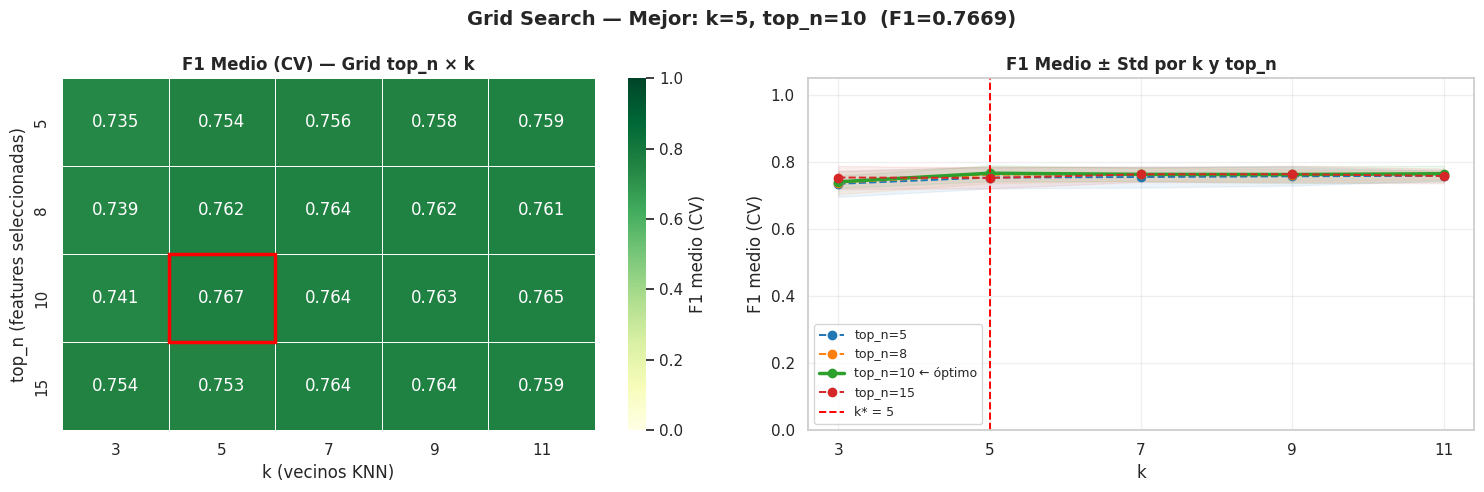

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel izq: Heatmap F1 medio — top_n × k 
pivot = df_cv.pivot(index="top_n", columns="k", values="F1_media")
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGn",
            linewidths=0.4, ax=axes[0], vmin=0, vmax=1,
            cbar_kws={"label": "F1 medio (CV)"})
# Marcar la mejor combinación
best_row_idx = list(TOPN_VALUES).index(best_top_n)
best_col_idx = list(K_VALUES).index(best_k)
axes[0].add_patch(plt.Rectangle((best_col_idx, best_row_idx), 1, 1,
                                  fill=False, edgecolor="red", lw=2.5))
axes[0].set_title("F1 Medio (CV) — Grid top_n × k", fontweight="bold")
axes[0].set_xlabel("k (vecinos KNN)")
axes[0].set_ylabel("top_n (features seleccionadas)")

# Panel der: F1 medio por k, una línea por top_n 
palette = plt.cm.tab10.colors
for idx, top_n in enumerate(TOPN_VALUES):
    sub = df_cv[df_cv["top_n"] == top_n]
    lw = 2.5 if top_n == best_top_n else 1.4
    ls = "-"  if top_n == best_top_n else "--"
    axes[1].plot(sub["k"], sub["F1_media"],
                 marker="o", lw=lw, linestyle=ls, color=palette[idx],
                 label=f"top_n={top_n}" + (" ← óptimo" if top_n==best_top_n else ""))
    axes[1].fill_between(sub["k"],
                          sub["F1_media"] - sub["F1_std"],
                          sub["F1_media"] + sub["F1_std"],
                          alpha=0.08, color=palette[idx])

axes[1].axvline(best_k, color="red", linestyle="--", lw=1.4,
                label=f"k* = {best_k}")
axes[1].set(xlabel="k", ylabel="F1 medio (CV)", xticks=K_VALUES,
            ylim=(0, 1.05))
axes[1].set_title("F1 Medio ± Std por k y top_n", fontweight="bold")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle(f"Grid Search — Mejor: k={best_k}, top_n={best_top_n}  "
             f"(F1={best_row['F1_media']:.4f})",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


## **Evaluación Final en Test**

Con `k*` elegido por CV, reentrenamos el pipeline sobre **todo X_trainval**
y evaluamos **una única vez** en test.


Evaluación en Test — KNN Clasificación (k=5, top_n=10)

  Métrica                 CV medio (F1)        Test
  ──────────────────────────────────────────────────
  Accuracy                            —      0.7020
  Balanced Accuracy                   —      0.6887
  Precision                           —      0.7857
  Recall                              —      0.7359
  F1-score                       0.7669      0.7600
  ROC AUC                             —      0.7701


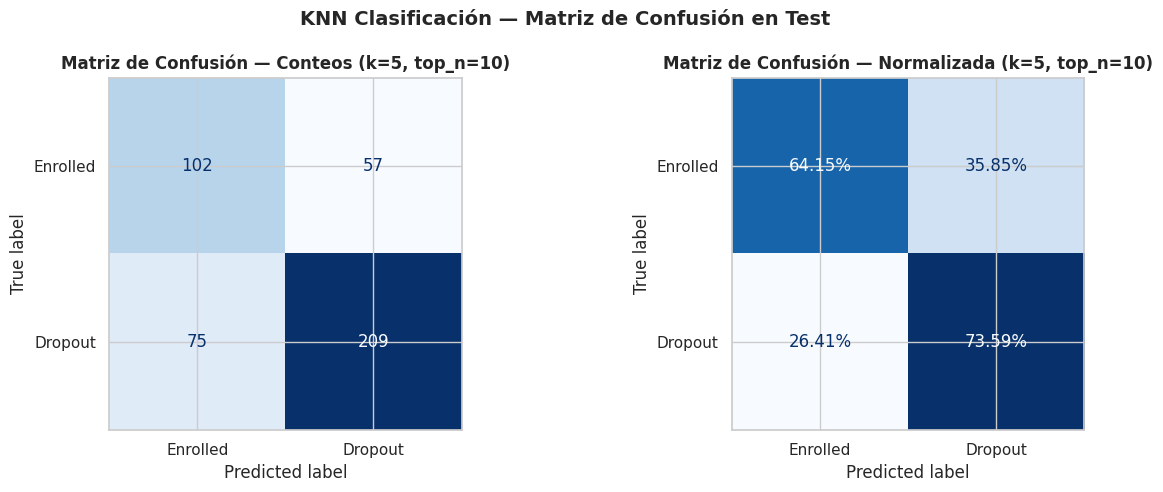


Reporte detallado:
              precision    recall  f1-score   support

    Enrolled       0.58      0.64      0.61       159
     Dropout       0.79      0.74      0.76       284

    accuracy                           0.70       443
   macro avg       0.68      0.69      0.68       443
weighted avg       0.71      0.70      0.71       443



In [95]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              precision_score, recall_score,
                              f1_score, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
import matplotlib.pyplot as plt

pipe_best = make_clf_pipeline(best_k, best_top_n)
pipe_best.fit(X_trainval_raw, y_clf_trainval)

y_pred_test  = pipe_best.predict(X_test_raw)
y_proba_test = pipe_best.predict_proba(X_test_raw)[:, 1]

metrics_test = {
    "Accuracy"         : accuracy_score(y_clf_test, y_pred_test),
    "Balanced Accuracy": balanced_accuracy_score(y_clf_test, y_pred_test),
    "Precision"        : precision_score(y_clf_test, y_pred_test, zero_division=0),
    "Recall"           : recall_score(y_clf_test, y_pred_test, zero_division=0),
    "F1-score"         : f1_score(y_clf_test, y_pred_test, zero_division=0),
    "ROC AUC"          : roc_auc_score(y_clf_test, y_proba_test),
}

print(f"Evaluación en Test — KNN Clasificación (k={best_k}, top_n={best_top_n})\n")
print(f"  {'Métrica':<22} {'CV medio (F1)':>14}  {'Test':>10}")
print("  " + "─" * 50)
for met, val in metrics_test.items():
    cv_ref = f"{best_row['F1_media']:.4f}" if met == "F1-score" else "—"
    print(f"  {met:<22} {cv_ref:>14}  {val:>10.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm      = confusion_matrix(y_clf_test, y_pred_test)
cm_norm = confusion_matrix(y_clf_test, y_pred_test, normalize="true")
ConfusionMatrixDisplay(cm, display_labels=["Enrolled","Dropout"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Matriz de Confusión — Conteos (k={best_k}, top_n={best_top_n})",
                   fontweight="bold")
ConfusionMatrixDisplay(cm_norm, display_labels=["Enrolled","Dropout"]).plot(
    ax=axes[1], colorbar=False, cmap="Blues", values_format=".2%")
axes[1].set_title(f"Matriz de Confusión — Normalizada (k={best_k}, top_n={best_top_n})",
                   fontweight="bold")
plt.suptitle("KNN Clasificación — Matriz de Confusión en Test",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

print("\nReporte detallado:")
print(classification_report(y_clf_test, y_pred_test,
                             target_names=["Enrolled","Dropout"]))


---
## **Curva ROC / AUC**

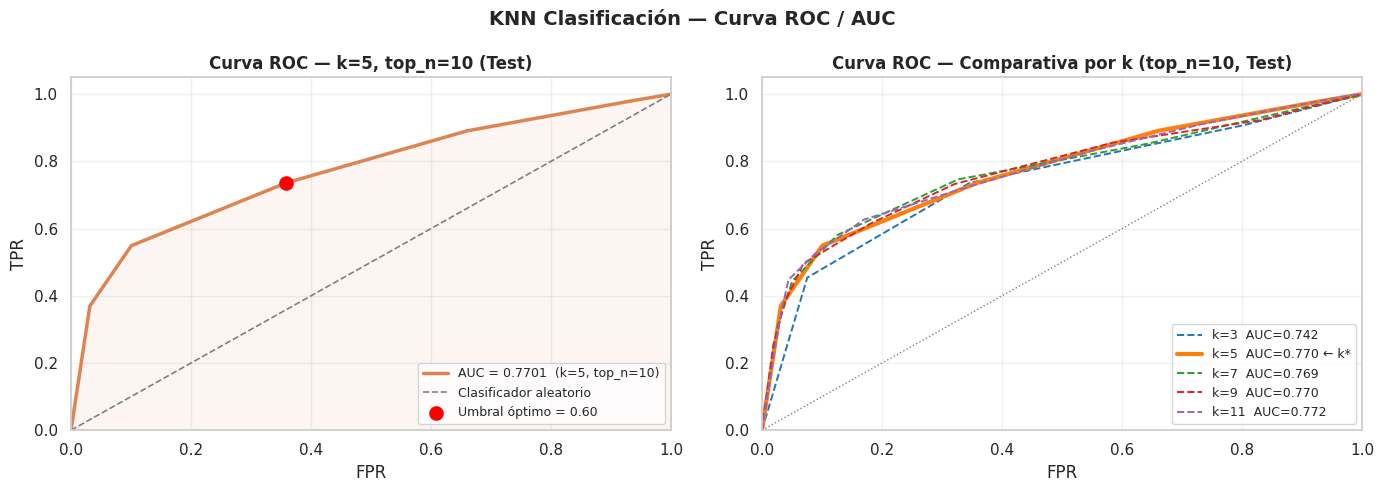

In [96]:
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, thresholds = roc_curve(y_clf_test, y_proba_test)
roc_auc_best = auc(fpr, tpr)

axes[0].plot(fpr, tpr, color="#DD8452", lw=2.5,
             label=f"AUC = {roc_auc_best:.4f}  (k={best_k}, top_n={best_top_n})")
axes[0].fill_between(fpr, tpr, alpha=0.08, color="#DD8452")
axes[0].plot([0,1],[0,1], color="gray", lw=1.2, linestyle="--",
             label="Clasificador aleatorio")
dist    = np.sqrt(fpr**2 + (1 - tpr)**2)
opt_idx = np.argmin(dist)
axes[0].scatter(fpr[opt_idx], tpr[opt_idx], s=90, color="red", zorder=5,
                label=f"Umbral óptimo = {thresholds[opt_idx]:.2f}")
axes[0].set(xlim=[0,1], ylim=[0,1.05], xlabel="FPR", ylabel="TPR")
axes[0].set_title(f"Curva ROC — k={best_k}, top_n={best_top_n} (Test)",
                   fontweight="bold")
axes[0].legend(loc="lower right", fontsize=9); axes[0].grid(alpha=0.3)

palette = plt.cm.tab10.colors
for idx, k in enumerate(K_VALUES):
    p = make_clf_pipeline(k, best_top_n)
    p.fit(X_trainval_raw, y_clf_trainval)
    fpr_k, tpr_k, _ = roc_curve(y_clf_test, p.predict_proba(X_test_raw)[:, 1])
    axes[1].plot(fpr_k, tpr_k,
                 lw=3.0 if k==best_k else 1.4,
                 linestyle="-" if k==best_k else "--",
                 color=palette[idx],
                 label=f"k={k}  AUC={auc(fpr_k,tpr_k):.3f}" +
                       (" ← k*" if k==best_k else ""))

axes[1].plot([0,1],[0,1], color="gray", lw=1, linestyle=":")
axes[1].set(xlim=[0,1], ylim=[0,1.05], xlabel="FPR", ylabel="TPR")
axes[1].set_title(f"Curva ROC — Comparativa por k (top_n={best_top_n}, Test)",
                   fontweight="bold")
axes[1].legend(loc="lower right", fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle("KNN Clasificación — Curva ROC / AUC",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()



### **Impacto de `k` en el Desempeño**

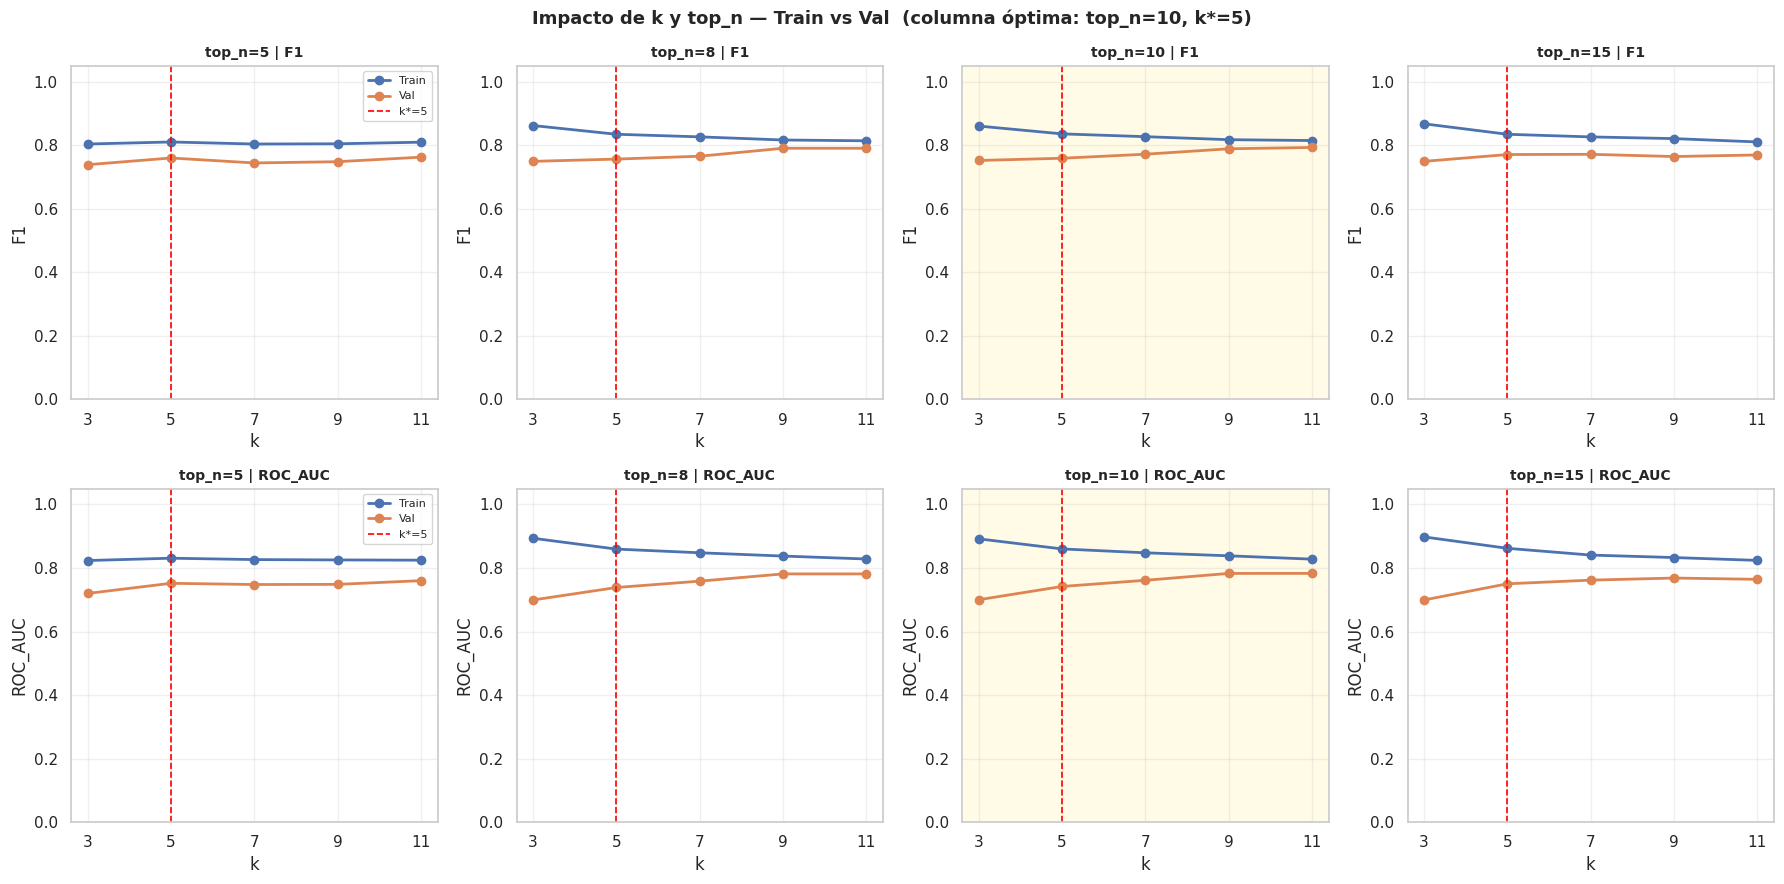


Resumen Val — top_n=10:


,F1,ROC_AUC,Recall
k,,,
3,0.752200,0.700200,0.758800
5,0.759200,0.742000,0.767500
7,0.771900,0.761400,0.793900
9,0.788900,0.783000,0.811400
11,0.793200,0.783200,0.815800


In [97]:
records = []
for top_n in TOPN_VALUES:
    for k in K_VALUES:
        p = make_clf_pipeline(k, top_n)
        p.fit(X_train_raw, y_clf_train)
        for split_name, X_s, y_s in [("Train", X_train_raw, y_clf_train),
                                       ("Val",   X_val_raw,   y_clf_val)]:
            y_p  = p.predict(X_s)
            y_pr = p.predict_proba(X_s)[:, 1]
            records.append({
                "k"       : k,
                "top_n"   : top_n,
                "Split"   : split_name,
                "F1"      : f1_score(y_s, y_p, zero_division=0),
                "ROC_AUC" : roc_auc_score(y_s, y_pr),
                "Recall"  : recall_score(y_s, y_p, zero_division=0),
            })

df_k = pd.DataFrame(records)

# Un subplot por top_n, curvas Train vs Val por k 
fig, axes = plt.subplots(2, len(TOPN_VALUES), figsize=(18, 9))
colors_split = {"Train": "#4C72B0", "Val": "#DD8452"}
metrics_plot = ["F1", "ROC_AUC"]

for col, top_n in enumerate(TOPN_VALUES):
    sub = df_k[df_k["top_n"] == top_n]
    for row, met in enumerate(metrics_plot):
        ax = axes[row][col]
        for split, grp in sub.groupby("Split"):
            ax.plot(grp["k"], grp[met], marker="o", lw=2,
                    label=split, color=colors_split[split])
        ax.axvline(best_k, color="red", linestyle="--", lw=1.2,
                   label=f"k*={best_k}" if col==0 else "")
        if top_n == best_top_n:
            ax.set_facecolor("#fffbe6")  # fondo amarillo en columna óptima
        ax.set(xticks=K_VALUES, ylim=(0, 1.05), xlabel="k", ylabel=met)
        ax.set_title(f"top_n={top_n} | {met}", fontweight="bold", fontsize=10)
        ax.grid(alpha=0.3)
        if col == 0:
            ax.legend(fontsize=8)

plt.suptitle(f"Impacto de k y top_n — Train vs Val  "
             f"(columna óptima: top_n={best_top_n}, k*={best_k})",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# Tabla resumen Val para combinación óptima
print(f"\nResumen Val — top_n={best_top_n}:")
display(df_k[(df_k["top_n"]==best_top_n) & (df_k["Split"]=="Val")]
        .set_index("k")[["F1","ROC_AUC","Recall"]]
        .round(4)
        .style.highlight_max(axis=0, color="#a8d5a2"))
